# EEEM068 - Prompt Tuning CLIP: EuroSAT
## Zero-Shot Baselines (80 Handcrafted Prompts) + CuPL (LLM-Generated Prompts)

**Notebook structure**
1. Install dependencies
2. Imports & device setup
3. Mount Google Drive, extract dataset, load CLIP & DataLoaders
4. Shared helper functions (`zeroshot_classifier`, `evaluate`, `evaluate_with_features`)
5. Single-prompt zero-shot sanity check
6. **80 handcrafted prompts** - per-prompt accuracy, mean & variance
7. **CuPL prompt generation** local LLM fallback
8. CuPL evaluation vs 80-prompt ensemble baseline
9. Method comparison chart
10. Text-to-image attention maps (occlusion sensitivity)
11. Hyperparameter ablation - effect of prompt diversity N


## 1. Install Dependencies

In [1]:
!pip install -q git+https://github.com/openai/CLIP.git
!pip install google-genai --quiet
!pip install transformers accelerate bitsandbytes sentencepiece --quiet

## 2. Imports & Device Setup

In [2]:
import os
import json
import time
import re
import shutil
import zipfile

import numpy as np
import torch
import clip
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from torchvision import datasets
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: No GPU detected - Runtime > Change runtime type > T4 GPU")
from PIL import Image

# Import dataset classes from local module to enable multiprocessing on Windows
from cupl_datasets import FGVCAircraftDataset, GenericJSONSplitDataset

Using device: cuda


## 3. Find & Extract Dataset & Load CLIP

- `DATASET_NAME` - change this one line to switch datasets
- `CLASSES` provides human-readable names for CLIP text encoding
- `clip_model` is loaded as ViT-B/16 (frozen throughout)

In [3]:
# ============================================================================
# CHANGE ONLY THIS LINE to switch datasets
DATASET_NAME = 'food101'
# options:
# 'eurosat', 'caltech101', 'oxford_pets', 'dtd', 'flowers102', 
# 'food101', 'fgvc_aircraft', 'stanford_cars', 'ucf101'
# ============================================================================

# Per-dataset config
# local_subpath : folder inside DATASETS_DIR that contains the dataset zip
# classes : human-readable class names in ImageFolder alphabetical order (used for CLIP text encoding - must match folder sort order)
# folder_map : {folder_name: readable_name} for reference / debugging

DATASET_CONFIGS = {

    'eurosat': {
        'local_subpath': 'EuroSAT',
        'split_json': 'split_zhou_EuroSAT.json',
        'classes': [
            'Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway',
            'Industrial', 'Pasture', 'Permanent Crop', 'Residential',
            'River', 'Sea Lake',
        ],
        'folder_map': {
            'AnnualCrop': 'Annual Crop', 'Forest': 'Forest',
            'HerbaceousVegetation': 'Herbaceous Vegetation', 'Highway': 'Highway',
            'Industrial': 'Industrial', 'Pasture': 'Pasture',
            'PermanentCrop': 'Permanent Crop', 'Residential': 'Residential',
            'River': 'River', 'SeaLake': 'Sea Lake',
        },
    },

    'caltech101': {
        'local_subpath': 'Caltech101',
        'split_json': 'split_zhou_Caltech101.json',
        'classes': [
            'background', 'off-center face', 'centered face', 'leopard',
            'motorbike', 'accordion', 'airplane', 'anchor', 'ant', 'barrel',
            'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus',
            'buddha', 'butterfly', 'camera', 'cannon', 'side of a car',
            'ceiling fan', 'cellphone', 'chair', 'chandelier',
            'body of a cougar cat', 'face of a cougar cat', 'crab', 'crayfish',
            'crocodile', 'head of a crocodile', 'cup', 'dalmatian',
            'dollar bill', 'dolphin', 'dragonfly', 'electric guitar', 'elephant',
            'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'head of a flamingo',
            'garfield', 'gerenuk', 'gramophone', 'grand piano', 'hawksbill',
            'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline skate',
            'joshua tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama',
            'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome',
            'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda',
            'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino',
            'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion',
            'sea horse', 'snoopy (cartoon beagle)', 'soccer ball', 'stapler',
            'starfish', 'stegosaurus', 'stop sign', 'strawberry', 'sunflower',
            'tick', 'trilobite', 'umbrella', 'watch', 'water lilly',
            'wheelchair', 'wild cat', 'windsor chair', 'wrench',
            'yin and yang symbol',
        ],
        'folder_map': {
            'BACKGROUND_Google': 'background', 'Faces': 'off-center face',
            'Faces_easy': 'centered face', 'Leopards': 'leopard',
            'Motorbikes': 'motorbike', 'accordion': 'accordion',
            'airplanes': 'airplane', 'anchor': 'anchor', 'ant': 'ant',
            'barrel': 'barrel', 'bass': 'bass', 'beaver': 'beaver',
            'binocular': 'binocular', 'bonsai': 'bonsai', 'brain': 'brain',
            'brontosaurus': 'brontosaurus', 'buddha': 'buddha',
            'butterfly': 'butterfly', 'camera': 'camera', 'cannon': 'cannon',
            'car_side': 'side of a car', 'ceiling_fan': 'ceiling fan',
            'cellphone': 'cellphone', 'chair': 'chair', 'chandelier': 'chandelier',
            'cougar_body': 'body of a cougar cat', 'cougar_face': 'face of a cougar cat',
            'crab': 'crab', 'crayfish': 'crayfish', 'crocodile': 'crocodile',
            'crocodile_head': 'head of a crocodile', 'cup': 'cup',
            'dalmatian': 'dalmatian', 'dollar_bill': 'dollar bill',
            'dolphin': 'dolphin', 'dragonfly': 'dragonfly',
            'electric_guitar': 'electric guitar', 'elephant': 'elephant',
            'emu': 'emu', 'euphonium': 'euphonium', 'ewer': 'ewer',
            'ferry': 'ferry', 'flamingo': 'flamingo',
            'flamingo_head': 'head of a flamingo', 'garfield': 'garfield',
            'gerenuk': 'gerenuk', 'gramophone': 'gramophone',
            'grand_piano': 'grand piano', 'hawksbill': 'hawksbill',
            'headphone': 'headphone', 'hedgehog': 'hedgehog',
            'helicopter': 'helicopter', 'ibis': 'ibis',
            'inline_skate': 'inline skate', 'joshua_tree': 'joshua tree',
            'kangaroo': 'kangaroo', 'ketch': 'ketch', 'lamp': 'lamp',
            'laptop': 'laptop', 'llama': 'llama', 'lobster': 'lobster',
            'lotus': 'lotus', 'mandolin': 'mandolin', 'mayfly': 'mayfly',
            'menorah': 'menorah', 'metronome': 'metronome', 'minaret': 'minaret',
            'nautilus': 'nautilus', 'octopus': 'octopus', 'okapi': 'okapi',
            'pagoda': 'pagoda', 'panda': 'panda', 'pigeon': 'pigeon',
            'pizza': 'pizza', 'platypus': 'platypus', 'pyramid': 'pyramid',
            'revolver': 'revolver', 'rhino': 'rhino', 'rooster': 'rooster',
            'saxophone': 'saxophone', 'schooner': 'schooner',
            'scissors': 'scissors', 'scorpion': 'scorpion',
            'sea_horse': 'sea horse', 'snoopy': 'snoopy (cartoon beagle)',
            'soccer_ball': 'soccer ball', 'stapler': 'stapler',
            'starfish': 'starfish', 'stegosaurus': 'stegosaurus',
            'stop_sign': 'stop sign', 'strawberry': 'strawberry',
            'sunflower': 'sunflower', 'tick': 'tick', 'trilobite': 'trilobite',
            'umbrella': 'umbrella', 'watch': 'watch', 'water_lilly': 'water lilly',
            'wheelchair': 'wheelchair', 'wild_cat': 'wild cat',
            'windsor_chair': 'windsor chair', 'wrench': 'wrench',
            'yin_yang': 'yin and yang symbol',
        },
    },

    'oxford_pets': {
        'local_subpath': 'OxfordPets',
        'split_json': 'split_zhou_OxfordPets.json',
        'images_subpath': 'OxfordPets/images',  # nested after zip extraction
        'classes': [
            'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair',
            'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue',
            'Siamese', 'Sphynx', 'american bulldog', 'american pit bull terrier',
            'basset hound', 'beagle', 'boxer', 'chihuahua', 'english cocker spaniel',
            'english setter', 'german shorthaired', 'great pyrenees', 'havanese',
            'japanese chin', 'keeshond', 'leonberger', 'miniature pinscher',
            'newfoundland', 'pomeranian', 'pug', 'saint bernard', 'samoyed',
            'scottish terrier', 'shiba inu', 'staffordshire bull terrier',
            'wheaten terrier', 'yorkshire terrier',
        ],
        'folder_map': {
            'Abyssinian': 'Abyssinian', 'Bengal': 'Bengal', 'Birman': 'Birman',
            'Bombay': 'Bombay', 'British_Shorthair': 'British Shorthair',
            'Egyptian_Mau': 'Egyptian Mau', 'Maine_Coon': 'Maine Coon',
            'Persian': 'Persian', 'Ragdoll': 'Ragdoll', 'Russian_Blue': 'Russian Blue',
            'Siamese': 'Siamese', 'Sphynx': 'Sphynx',
            'american_bulldog': 'american bulldog',
            'american_pit_bull_terrier': 'american pit bull terrier',
            'basset_hound': 'basset hound', 'beagle': 'beagle', 'boxer': 'boxer',
            'chihuahua': 'chihuahua', 'english_cocker_spaniel': 'english cocker spaniel',
            'english_setter': 'english setter', 'german_shorthaired': 'german shorthaired',
            'great_pyrenees': 'great pyrenees', 'havanese': 'havanese',
            'japanese_chin': 'japanese chin', 'keeshond': 'keeshond',
            'leonberger': 'leonberger', 'miniature_pinscher': 'miniature pinscher',
            'newfoundland': 'newfoundland', 'pomeranian': 'pomeranian', 'pug': 'pug',
            'saint_bernard': 'saint bernard', 'samoyed': 'samoyed',
            'scottish_terrier': 'scottish terrier', 'shiba_inu': 'shiba inu',
            'staffordshire_bull_terrier': 'staffordshire bull terrier',
            'wheaten_terrier': 'wheaten terrier', 'yorkshire_terrier': 'yorkshire terrier',
        },
    },

    'flowers102': {
        'local_subpath': 'Flowers102',
        'split_json':     'split_zhou_OxfordFlowers.json',
        'images_subpath': 'jpg',          # flat dir inside extracted 102flowers.tgz
        'classes': [
            'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells',
            'sweet pea', 'english marigold', 'tiger lily', 'moon orchid',
            'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon',
            "colt's foot", 'king protea', 'spear thistle', 'yellow iris',
            'globe flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
            'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary',
            'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers',
            'stemless gentian', 'artichoke', 'sweet william', 'carnation',
            'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly',
            'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip',
            'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia',
            'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy',
            'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower',
            'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia',
            'pink and yellow dahlia', 'cautleya spicata', 'japanese anemone',
            'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum',
            'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania',
            'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory',
            'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani',
            'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow',
            'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum',
            'bee balm', 'air plant', 'foxglove', 'bougainvillea', 'camellia',
            'mallow', 'mexican petunia', 'bromelia', 'blanket flower',
            'trumpet creeper', 'blackberry lily',
        ],
        'folder_map': {},   # not used - splits come from split_json
    },

    'fgvc_aircraft': {
        'local_subpath':    'FGVCAircraft',
        'images_subpath':   'fgvc-aircraft-2013b/data/images',     # flat jpg dir inside extracted zip
        'annotation_level': 'variant',    # drives which txt files are read can be 'variant', 'manufacturer', 'family'
        'classes': [
            '707-320', '727-200', '737-200', '737-300', '737-400', '737-500',
            '737-600', '737-700', '737-800', '737-900', '747-100', '747-200',
            '747-300', '747-400', '757-200', '757-300', '767-200', '767-300',
            '767-400', '777-200', '777-300', 'A300B4', 'A310', 'A318', 'A319',
            'A320', 'A321', 'A330-200', 'A330-300', 'A340-200', 'A340-300',
            'A340-500', 'A340-600', 'A380', 'ATR-42', 'ATR-72', 'An-12',
            'BAE 146-200', 'BAE 146-300', 'BAE-125', 'Beechcraft 1900',
            'Boeing 717', 'C-130', 'C-47', 'CRJ-200', 'CRJ-700', 'CRJ-900',
            'Cessna 172', 'Cessna 208', 'Cessna 525', 'Cessna 560',
            'Challenger 600', 'DC-10', 'DC-3', 'DC-6', 'DC-8', 'DC-9-30',
            'DH-82', 'DHC-1', 'DHC-6', 'DHC-8-100', 'DHC-8-300', 'DR-400',
            'Dornier 328', 'E-170', 'E-190', 'E-195', 'EMB-120', 'ERJ 135',
            'ERJ 145', 'Embraer Legacy 600', 'Eurofighter Typhoon', 'F-16A/B',
            'F/A-18', 'Falcon 2000', 'Falcon 900', 'Fokker 100', 'Fokker 50',
            'Fokker 70', 'Global Express', 'Gulfstream IV', 'Gulfstream V',
            'Hawk T1', 'Il-76', 'L-1011', 'MD-11', 'MD-80', 'MD-87', 'MD-90',
            'Metroliner', 'Model B200', 'PA-28', 'SR-20', 'Saab 2000',
            'Saab 340', 'Spitfire', 'Tornado', 'Tu-134', 'Tu-154', 'Yak-42',
        ],
        'folder_map': {},   # not used - splits come from images_variant_*.txt on Drive
    },

    'food101': {
        'local_subpath':  'Food101',
        'split_json':     'split_zhou_Food101.json',
        'images_subpath': 'food-101/images',  # nested after tar.gz extraction
        'classes': [
            'apple pie', 'baby back ribs', 'baklava', 'beef carpaccio', 'beef tartare',
            'beet salad', 'beignets', 'bibimbap', 'bread pudding', 'breakfast burrito', 'bruschetta',
            'caesar salad', 'cannoli', 'caprese salad', 'carrot cake', 'ceviche', 'cheese plate',
            'cheesecake', 'chicken curry', 'chicken quesadilla', 'chicken wings', 'chocolate cake',
            'chocolate mousse', 'churros', 'clam chowder', 'club sandwich', 'crab cakes', 'creme brulee',
            'croque madame', 'cup cakes', 'deviled eggs', 'donuts', 'dumplings', 'edamame', 'eggs benedict',
            'escargots', 'falafel', 'filet mignon', 'fish and chips', 'foie gras', 'french fries',
            'french onion soup', 'french toast', 'fried calamari', 'fried rice', 'frozen yogurt', 'garlic bread',
            'gnocchi', 'greek salad', 'grilled cheese sandwich', 'grilled salmon', 'guacamole', 'gyoza',
            'hamburger', 'hot and sour soup', 'hot dog', 'huevos rancheros', 'hummus', 'ice cream', 'lasagna',
            'lobster bisque', 'lobster roll sandwich', 'macaroni and cheese', 'macarons', 'miso soup', 'mussels',
            'nachos', 'omelette', 'onion rings', 'oysters', 'pad thai', 'paella', 'pancakes', 'panna cotta',
            'peking duck', 'pho', 'pizza', 'pork chop', 'poutine', 'prime rib', 'pulled pork sandwich', 'ramen',
            'ravioli', 'red velvet cake', 'risotto', 'samosa', 'sashimi', 'scallops', 'seaweed salad', 'shrimp and grits',
            'spaghetti bolognese', 'spaghetti carbonara', 'spring rolls', 'steak', 'strawberry shortcake', 'sushi', 'tacos',
            'takoyaki', 'tiramisu', 'tuna tartare', 'waffles'
        ],
        'folder_map': {
            'apple_pie': 'apple pie', 'baby_back_ribs': 'baby back ribs', 'baklava': 'baklava', 'beef_carpaccio': 'beef carpaccio',
            'beef_tartare': 'beef tartare', 'beet_salad': 'beet salad', 'beignets': 'beignets', 'bibimbap': 'bibimbap',
            'bread_pudding': 'bread pudding', 'breakfast_burrito': 'breakfast burrito', 'bruschetta': 'bruschetta',
            'caesar_salad': 'caesar salad', 'cannoli': 'cannoli', 'caprese_salad': 'caprese salad', 'carrot_cake': 'carrot cake',
            'ceviche': 'ceviche', 'cheese_plate': 'cheese plate', 'cheesecake': 'cheesecake', 'chicken_curry': 'chicken curry',
            'chicken_quesadilla': 'chicken quesadilla', 'chicken_wings': 'chicken wings', 'chocolate_cake': 'chocolate cake',
            'chocolate_mousse': 'chocolate mousse', 'churros': 'churros', 'clam_chowder': 'clam chowder', 'club_sandwich': 'club sandwich',
            'crab_cakes': 'crab cakes', 'creme_brulee': 'creme brulee', 'croque_madame': 'croque madame', 'cup_cakes': 'cup cakes',
            'deviled_eggs': 'deviled eggs', 'donuts': 'donuts', 'dumplings': 'dumplings', 'edamame': 'edamame', 'eggs_benedict': 'eggs benedict',
            'escargots': 'escargots', 'falafel': 'falafel', 'filet_mignon': 'filet mignon', 'fish_and_chips': 'fish and chips',
            'foie_gras': 'foie gras', 'french_fries': 'french fries', 'french_onion_soup': 'french onion soup', 'french_toast': 'french toast',
            'fried_calamari': 'fried calamari', 'fried_rice': 'fried rice', 'frozen_yogurt': 'frozen yogurt', 'garlic_bread': 'garlic bread',
            'gnocchi': 'gnocchi', 'greek_salad': 'greek salad', 'grilled_cheese_sandwich': 'grilled cheese sandwich',
            'grilled_salmon': 'grilled salmon', 'guacamole': 'guacamole', 'gyoza': 'gyoza', 'hamburger': 'hamburger',
            'hot_and_sour_soup': 'hot and sour soup', 'hot_dog': 'hot dog', 'huevos_rancheros': 'huevos rancheros', 'hummus': 'hummus',
            'ice_cream': 'ice cream', 'lasagna': 'lasagna', 'lobster_bisque': 'lobster bisque', 'lobster_roll_sandwich': 'lobster roll sandwich',
            'macaroni_and_cheese': 'macaroni and cheese', 'macarons': 'macarons', 'miso_soup': 'miso soup', 'mussels': 'mussels', 'nachos': 'nachos',
            'omelette': 'omelette', 'onion_rings': 'onion rings', 'oysters': 'oysters', 'pad_thai': 'pad thai', 'paella': 'paella',
            'pancakes': 'pancakes', 'panna_cotta': 'panna cotta', 'peking_duck': 'peking duck', 'pho': 'pho', 'pizza': 'pizza',
            'pork_chop': 'pork chop', 'poutine': 'poutine', 'prime_rib': 'prime rib', 'pulled_pork_sandwich': 'pulled pork sandwich',
            'ramen': 'ramen', 'ravioli': 'ravioli', 'red_velvet_cake': 'red velvet cake', 'risotto': 'risotto', 'samosa': 'samosa',
            'sashimi': 'sashimi', 'scallops': 'scallops', 'seaweed_salad': 'seaweed salad', 'shrimp_and_grits': 'shrimp and grits',
            'spaghetti_bolognese': 'spaghetti bolognese', 'spaghetti_carbonara': 'spaghetti carbonara', 'spring_rolls': 'spring rolls',
            'steak': 'steak', 'strawberry_shortcake': 'strawberry shortcake', 'sushi': 'sushi', 'tacos': 'tacos', 'takoyaki': 'takoyaki',
            'tiramisu': 'tiramisu', 'tuna_tartare': 'tuna tartare', 'waffles': 'waffles'
        },
    },

    'stanford_cars': {
        'local_subpath': 'StanfordCars',
        'split_json':    'split_zhou_StanfordCars.json',
        # No images_subpath - filenames in JSON already include cars_train/ or cars_test/
        # so img_dir is set to EXTRACTED_DATASET_PATH directly after extraction
        'classes': [
            'AM General Hummer SUV 2000', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008',
            'Acura TSX Sedan 2012', 'Acura Integra Type R 2001', 'Acura ZDX Hatchback 2012',
            'Aston Martin V8 Vantage Convertible 2012', 'Aston Martin V8 Vantage Coupe 2012',
            'Aston Martin Virage Convertible 2012', 'Aston Martin Virage Coupe 2012', 'Audi RS 4 Convertible 2008',
            'Audi A5 Coupe 2012', 'Audi TTS Coupe 2012', 'Audi R8 Coupe 2012', 'Audi V8 Sedan 1994', 'Audi 100 Sedan 1994',
            'Audi 100 Wagon 1994', 'Audi TT Hatchback 2011', 'Audi S6 Sedan 2011', 'Audi S5 Convertible 2012', 'Audi S5 Coupe 2012',
            'Audi S4 Sedan 2012', 'Audi S4 Sedan 2007', 'Audi TT RS Coupe 2012', 'BMW ActiveHybrid 5 Sedan 2012',
            'BMW 1 Series Convertible 2012', 'BMW 1 Series Coupe 2012', 'BMW 3 Series Sedan 2012', 'BMW 3 Series Wagon 2012',
            'BMW 6 Series Convertible 2007', 'BMW X5 SUV 2007', 'BMW X6 SUV 2012', 'BMW M3 Coupe 2012', 'BMW M5 Sedan 2010',
            'BMW M6 Convertible 2010', 'BMW X3 SUV 2012', 'BMW Z4 Convertible 2012', 'Bentley Continental Supersports Conv. Convertible 2012',
            'Bentley Arnage Sedan 2009', 'Bentley Mulsanne Sedan 2011', 'Bentley Continental GT Coupe 2012',
            'Bentley Continental GT Coupe 2007', 'Bentley Continental Flying Spur Sedan 2007', 'Bugatti Veyron 16.4 Convertible 2009',
            'Bugatti Veyron 16.4 Coupe 2009', 'Buick Regal GS 2012', 'Buick Rainier SUV 2007', 'Buick Verano Sedan 2012',
            'Buick Enclave SUV 2012', 'Cadillac CTS-V Sedan 2012', 'Cadillac SRX SUV 2012', 'Cadillac Escalade EXT Crew Cab 2007',
            'Chevrolet Silverado 1500 Hybrid Crew Cab 2012', 'Chevrolet Corvette Convertible 2012', 'Chevrolet Corvette ZR1 2012',
            'Chevrolet Corvette Ron Fellows Edition Z06 2007', 'Chevrolet Traverse SUV 2012', 'Chevrolet Camaro Convertible 2012',
            'Chevrolet HHR SS 2010', 'Chevrolet Impala Sedan 2007', 'Chevrolet Tahoe Hybrid SUV 2012', 'Chevrolet Sonic Sedan 2012',
            'Chevrolet Express Cargo Van 2007', 'Chevrolet Avalanche Crew Cab 2012', 'Chevrolet Cobalt SS 2010',
            'Chevrolet Malibu Hybrid Sedan 2010', 'Chevrolet TrailBlazer SS 2009', 'Chevrolet Silverado 2500HD Regular Cab 2012',
            'Chevrolet Silverado 1500 Classic Extended Cab 2007', 'Chevrolet Express Van 2007', 'Chevrolet Monte Carlo Coupe 2007',
            'Chevrolet Malibu Sedan 2007', 'Chevrolet Silverado 1500 Extended Cab 2012', 'Chevrolet Silverado 1500 Regular Cab 2012',
            'Chrysler Aspen SUV 2009', 'Chrysler Sebring Convertible 2010', 'Chrysler Town and Country Minivan 2012', 'Chrysler 300 SRT-8 2010',
            'Chrysler Crossfire Convertible 2008', 'Chrysler PT Cruiser Convertible 2008', 'Daewoo Nubira Wagon 2002', 'Dodge Caliber Wagon 2012',
            'Dodge Caliber Wagon 2007', 'Dodge Caravan Minivan 1997', 'Dodge Ram Pickup 3500 Crew Cab 2010', 'Dodge Ram Pickup 3500 Quad Cab 2009',
            'Dodge Sprinter Cargo Van 2009', 'Dodge Journey SUV 2012', 'Dodge Dakota Crew Cab 2010', 'Dodge Dakota Club Cab 2007',
            'Dodge Magnum Wagon 2008', 'Dodge Challenger SRT8 2011', 'Dodge Durango SUV 2012', 'Dodge Durango SUV 2007', 'Dodge Charger Sedan 2012',
            'Dodge Charger SRT-8 2009', 'Eagle Talon Hatchback 1998', 'FIAT 500 Abarth 2012', 'FIAT 500 Convertible 2012', 'Ferrari FF Coupe 2012',
            'Ferrari California Convertible 2012', 'Ferrari 458 Italia Convertible 2012', 'Ferrari 458 Italia Coupe 2012', 'Fisker Karma Sedan 2012',
            'Ford F-450 Super Duty Crew Cab 2012', 'Ford Mustang Convertible 2007', 'Ford Freestar Minivan 2007', 'Ford Expedition EL SUV 2009',
            'Ford Edge SUV 2012', 'Ford Ranger SuperCab 2011', 'Ford GT Coupe 2006', 'Ford F-150 Regular Cab 2012', 'Ford F-150 Regular Cab 2007',
            'Ford Focus Sedan 2007', 'Ford E-Series Wagon Van 2012', 'Ford Fiesta Sedan 2012', 'GMC Terrain SUV 2012', 'GMC Savana Van 2012',
            'GMC Yukon Hybrid SUV 2012', 'GMC Acadia SUV 2012', 'GMC Canyon Extended Cab 2012', 'Geo Metro Convertible 1993',
            'HUMMER H3T Crew Cab 2010', 'HUMMER H2 SUT Crew Cab 2009', 'Honda Odyssey Minivan 2012', 'Honda Odyssey Minivan 2007',
            'Honda Accord Coupe 2012', 'Honda Accord Sedan 2012', 'Hyundai Veloster Hatchback 2012', 'Hyundai Santa Fe SUV 2012',
            'Hyundai Tucson SUV 2012', 'Hyundai Veracruz SUV 2012', 'Hyundai Sonata Hybrid Sedan 2012', 'Hyundai Elantra Sedan 2007',
            'Hyundai Accent Sedan 2012', 'Hyundai Genesis Sedan 2012', 'Hyundai Sonata Sedan 2012', 'Hyundai Elantra Touring Hatchback 2012',
            'Hyundai Azera Sedan 2012', 'Infiniti G Coupe IPL 2012', 'Infiniti QX56 SUV 2011', 'Isuzu Ascender SUV 2008', 'Jaguar XK XKR 2012',
            'Jeep Patriot SUV 2012', 'Jeep Wrangler SUV 2012', 'Jeep Liberty SUV 2012', 'Jeep Grand Cherokee SUV 2012', 'Jeep Compass SUV 2012',
            'Lamborghini Reventon Coupe 2008', 'Lamborghini Aventador Coupe 2012', 'Lamborghini Gallardo LP 570-4 Superleggera 2012',
            'Lamborghini Diablo Coupe 2001', 'Land Rover Range Rover SUV 2012', 'Land Rover LR2 SUV 2012', 'Lincoln Town Car Sedan 2011',
            'MINI Cooper Roadster Convertible 2012', 'Maybach Landaulet Convertible 2012', 'Mazda Tribute SUV 2011', 'McLaren MP4-12C Coupe 2012',
            'Mercedes-Benz 300-Class Convertible 1993', 'Mercedes-Benz C-Class Sedan 2012', 'Mercedes-Benz SL-Class Coupe 2009',
            'Mercedes-Benz E-Class Sedan 2012', 'Mercedes-Benz S-Class Sedan 2012', 'Mercedes-Benz Sprinter Van 2012', 'Mitsubishi Lancer Sedan 2012',
            'Nissan Leaf Hatchback 2012', 'Nissan NV Passenger Van 2012', 'Nissan Juke Hatchback 2012', 'Nissan 240SX Coupe 1998',
            'Plymouth Neon Coupe 1999', 'Porsche Panamera Sedan 2012', 'Ram C/V Cargo Van Minivan 2012',
            'Rolls-Royce Phantom Drophead Coupe Convertible 2012', 'Rolls-Royce Ghost Sedan 2012', 'Rolls-Royce Phantom Sedan 2012',
            'Scion xD Hatchback 2012', 'Spyker C8 Convertible 2009', 'Spyker C8 Coupe 2009', 'Suzuki Aerio Sedan 2007',
            'Suzuki Kizashi Sedan 2012', 'Suzuki SX4 Hatchback 2012', 'Suzuki SX4 Sedan 2012', 'Tesla Model S Sedan 2012', 'Toyota Sequoia SUV 2012',
            'Toyota Camry Sedan 2012', 'Toyota Corolla Sedan 2012', 'Toyota 4Runner SUV 2012', 'Volkswagen Golf Hatchback 2012',
            'Volkswagen Golf Hatchback 1991', 'Volkswagen Beetle Hatchback 2012', 'Volvo C30 Hatchback 2012', 'Volvo 240 Sedan 1993',
            'Volvo XC90 SUV 2007', 'smart fortwo Convertible 2012'
        ],
        'folder_map': {},   # not used - label indices from JSON are used directly
    },

    'ucf101': {
        'local_subpath':  'UCF101',
        'split_json':     'split_zhou_UCF101.json',
        'images_subpath': 'UCF-101-midframes',
        'classes': [
            'Apply Eye Makeup', 'Apply Lipstick', 'Archery', 'Baby Crawling', 'Balance Beam', 'Band Marching', 'Baseball Pitch',
            'Basketball', 'Basketball Dunk', 'Bench Press', 'Biking', 'Billiards', 'Blow Dry Hair', 'Blowing Candles', 'Body Weight Squats',
            'Bowling', 'Boxing Punching Bag', 'Boxing Speed Bag', 'Breast Stroke', 'Brushing Teeth', 'Clean And Jerk', 'Cliff Diving',
            'Cricket Bowling', 'Cricket Shot', 'Cutting In Kitchen', 'Diving', 'Drumming', 'Fencing', 'Field Hockey Penalty',
            'Floor Gymnastics', 'Frisbee Catch', 'Front Crawl', 'Golf Swing', 'Haircut', 'Hammer Throw', 'Hammering', 'Hand Stand Pushups',
            'Handstand Walking', 'Head Massage', 'High Jump', 'Horse Race', 'Horse Riding', 'Hula Hoop', 'Ice Dancing', 'Javelin Throw',
            'Juggling Balls', 'Jump Rope', 'Jumping Jack', 'Kayaking', 'Knitting', 'Long Jump', 'Lunges', 'Military Parade', 'Mixing',
            'Mopping Floor', 'Nunchucks', 'Parallel Bars', 'Pizza Tossing', 'Playing Cello', 'Playing Daf', 'Playing Dhol', 'Playing Flute',
            'Playing Guitar', 'Playing Piano', 'Playing Sitar', 'Playing Tabla', 'Playing Violin', 'Pole Vault', 'Pommel Horse', 'Pull Ups',
            'Punch', 'Push Ups', 'Rafting', 'Rock Climbing Indoor', 'Rope Climbing', 'Rowing', 'Salsa Spin', 'Shaving Beard', 'Shotput',
            'Skate Boarding', 'Skiing', 'Skijet', 'Sky Diving', 'Soccer Juggling', 'Soccer Penalty', 'Still Rings', 'Sumo Wrestling', 'Surfing',
            'Swing', 'Table Tennis Shot', 'Tai Chi', 'Tennis Swing', 'Throw Discus', 'Trampoline Jumping', 'Typing', 'Uneven Bars',
            'Volleyball Spiking', 'Walking With Dog', 'Wall Pushups', 'Writing On Board', 'Yo Yo'
        ],
        'folder_map': {
            'Apply_Eye_Makeup': 'Apply Eye Makeup', 'Apply_Lipstick': 'Apply Lipstick', 'Archery': 'Archery', 'Baby_Crawling': 'Baby Crawling',
            'Balance_Beam': 'Balance Beam', 'Band_Marching': 'Band Marching', 'Baseball_Pitch': 'Baseball Pitch', 'Basketball': 'Basketball',
            'Basketball_Dunk': 'Basketball Dunk', 'Bench_Press': 'Bench Press', 'Biking': 'Biking', 'Billiards': 'Billiards',
            'Blow_Dry_Hair': 'Blow Dry Hair', 'Blowing_Candles': 'Blowing Candles', 'Body_Weight_Squats': 'Body Weight Squats', 'Bowling': 'Bowling',
            'Boxing_Punching_Bag': 'Boxing Punching Bag', 'Boxing_Speed_Bag': 'Boxing Speed Bag', 'Breast_Stroke': 'Breast Stroke',
            'Brushing_Teeth': 'Brushing Teeth', 'Clean_And_Jerk': 'Clean And Jerk', 'Cliff_Diving': 'Cliff Diving',
            'Cricket_Bowling': 'Cricket Bowling', 'Cricket_Shot': 'Cricket Shot', 'Cutting_In_Kitchen': 'Cutting In Kitchen', 'Diving': 'Diving',
            'Drumming': 'Drumming', 'Fencing': 'Fencing', 'Field_Hockey_Penalty': 'Field Hockey Penalty', 'Floor_Gymnastics': 'Floor Gymnastics',
            'Frisbee_Catch': 'Frisbee Catch', 'Front_Crawl': 'Front Crawl', 'Golf_Swing': 'Golf Swing', 'Haircut': 'Haircut',
            'Hammer_Throw': 'Hammer Throw', 'Hammering': 'Hammering', 'Hand_Stand_Pushups': 'Hand Stand Pushups',
            'Handstand_Walking': 'Handstand Walking', 'Head_Massage': 'Head Massage', 'High_Jump': 'High Jump', 'Horse_Race': 'Horse Race',
            'Horse_Riding': 'Horse Riding', 'Hula_Hoop': 'Hula Hoop', 'Ice_Dancing': 'Ice Dancing', 'Javelin_Throw': 'Javelin Throw',
            'Juggling_Balls': 'Juggling Balls', 'Jump_Rope': 'Jump Rope', 'Jumping_Jack': 'Jumping Jack', 'Kayaking': 'Kayaking',
            'Knitting': 'Knitting', 'Long_Jump': 'Long Jump', 'Lunges': 'Lunges', 'Military_Parade': 'Military Parade', 'Mixing': 'Mixing',
            'Mopping_Floor': 'Mopping Floor', 'Nunchucks': 'Nunchucks', 'Parallel_Bars': 'Parallel Bars', 'Pizza_Tossing': 'Pizza Tossing',
            'Playing_Cello': 'Playing Cello', 'Playing_Daf': 'Playing Daf', 'Playing_Dhol': 'Playing Dhol', 'Playing_Flute': 'Playing Flute',
            'Playing_Guitar': 'Playing Guitar', 'Playing_Piano': 'Playing Piano', 'Playing_Sitar': 'Playing Sitar', 'Playing_Tabla': 'Playing Tabla',
            'Playing_Violin': 'Playing Violin', 'Pole_Vault': 'Pole Vault', 'Pommel_Horse': 'Pommel Horse', 'Pull_Ups': 'Pull Ups', 'Punch': 'Punch',
            'Push_Ups': 'Push Ups', 'Rafting': 'Rafting', 'Rock_Climbing_Indoor': 'Rock Climbing Indoor', 'Rope_Climbing': 'Rope Climbing',
            'Rowing': 'Rowing', 'Salsa_Spin': 'Salsa Spin', 'Shaving_Beard': 'Shaving Beard', 'Shotput': 'Shotput', 'Skate_Boarding': 'Skate Boarding',
            'Skiing': 'Skiing', 'Skijet': 'Skijet', 'Sky_Diving': 'Sky Diving', 'Soccer_Juggling': 'Soccer Juggling', 'Soccer_Penalty': 'Soccer Penalty',
            'Still_Rings': 'Still Rings', 'Sumo_Wrestling': 'Sumo Wrestling', 'Surfing': 'Surfing', 'Swing': 'Swing',
            'Table_Tennis_Shot': 'Table Tennis Shot', 'Tai_Chi': 'Tai Chi', 'Tennis_Swing': 'Tennis Swing', 'Throw_Discus': 'Throw Discus',
            'Trampoline_Jumping': 'Trampoline Jumping', 'Typing': 'Typing', 'Uneven_Bars': 'Uneven Bars', 'Volleyball_Spiking': 'Volleyball Spiking',
            'Walking_With_Dog': 'Walking With Dog', 'Wall_Pushups': 'Wall Pushups', 'Writing_On_Board': 'Writing On Board', 'Yo_Yo': 'Yo Yo'
        },
    },

    'dtd': {
        'local_subpath': 'DTD',
        'split_json': 'split_zhou_DescribableTextures.json',
        'images_subpath': 'dtd/images',
        'classes': [
            'banded', 'blotchy', 'braided', 'bubbly', 'bumpy',
            'chequered', 'cobwebbed', 'cracked', 'crosshatched', 'crystalline',
            'dotted', 'fibrous', 'flecked', 'freckled', 'frilly',
            'gauzy', 'grid', 'grooved', 'honeycombed', 'interlaced',
            'knitted', 'lacelike', 'lined', 'marbled', 'matted',
            'meshed', 'paisley', 'perforated', 'pitted', 'pleated',
            'polka-dotted', 'porous', 'potholed', 'scaly', 'smeared',
            'spiralled', 'sprinkled', 'stained', 'stratified', 'striped',
            'studded', 'swirly', 'veined', 'waffled', 'woven',
            'wrinkled', 'zigzagged',
        ],
        'folder_map': {
            'banded': 'banded', 'blotchy': 'blotchy', 'braided': 'braided',
            'bubbly': 'bubbly', 'bumpy': 'bumpy', 'chequered': 'chequered',
            'cobwebbed': 'cobwebbed', 'cracked': 'cracked',
            'crosshatched': 'crosshatched', 'crystalline': 'crystalline',
            'dotted': 'dotted', 'fibrous': 'fibrous', 'flecked': 'flecked',
            'freckled': 'freckled', 'frilly': 'frilly', 'gauzy': 'gauzy',
            'grid': 'grid', 'grooved': 'grooved', 'honeycombed': 'honeycombed',
            'interlaced': 'interlaced', 'knitted': 'knitted', 'lacelike': 'lacelike',
            'lined': 'lined', 'marbled': 'marbled', 'matted': 'matted',
            'meshed': 'meshed', 'paisley': 'paisley', 'perforated': 'perforated',
            'pitted': 'pitted', 'pleated': 'pleated', 'polka-dotted': 'polka-dotted',
            'porous': 'porous', 'potholed': 'potholed', 'scaly': 'scaly',
            'smeared': 'smeared', 'spiralled': 'spiralled', 'sprinkled': 'sprinkled',
            'stained': 'stained', 'stratified': 'stratified', 'striped': 'striped',
            'studded': 'studded', 'swirly': 'swirly', 'veined': 'veined',
            'waffled': 'waffled', 'woven': 'woven', 'wrinkled': 'wrinkled',
            'zigzagged': 'zigzagged',
        },
    },
}


## 3b. Reusable Dataset Loader

Wraps the dataset-loading logic into a single `load_single_dataset()` function
used by the master experiment loop.

**Base / New class split protocol** (CoOp / Zhou et al.):
The `split_zhou_*.json` files encode train/val/test *image* splits - all splits
cover *all* classes. The base/new *class* split is defined separately in the
CoOp/Dassl codebase as: sort all class names alphabetically -> first half = base
(seen), second half = new (unseen). This is equivalent to `n_cls // 2`, which
is what this notebook uses.

In [4]:
import pathlib, json as _json_mod, os, tarfile, zipfile
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split as _random_split


# Master function for loading unified dataset. 
# Connects the datasets chosen via `DATASET_NAME` with the pre-baked GenericJSONSplitDataset logic to extract standard loaders.
# Prevents redundant data traversal code entirely.
def load_single_dataset(dataset_name, datasets_dir='../Datasets', extracted_base='../Extracted_Datasets'):
    """
    Load one dataset by name. Returns
        classes       : list[str] human-readable class names (CLIP-friendly)
        train_dataset : Dataset  (train split only)
        val_dataset   : Dataset  (val split - kept separate for eval reporting)
        test_dataset  : Dataset  (held-out test split)
    Reuses: DATASET_CONFIGS, FGVCAircraftDataset, GenericJSONSplitDataset
    """
    assert dataset_name in DATASET_CONFIGS, f"Unknown dataset '{dataset_name}'. Available: {list(DATASET_CONFIGS)}"

    cfg = DATASET_CONFIGS[dataset_name]
    dataset_subpath = os.path.join(datasets_dir, cfg['local_subpath'])
    extracted_path = str(pathlib.Path(f"{extracted_base}/{dataset_name}").resolve())

    # 1. Resolve CLASSES from split JSON 
    if 'split_json' in cfg:
        split_json = os.path.join(dataset_subpath, cfg['split_json'])
    else:
        json_files = [f for f in os.listdir(dataset_subpath) if f.endswith('.json')]
        split_json = (os.path.join(dataset_subpath, json_files[0]) if json_files else None)
    split_data = None

    if split_json and dataset_name != 'fgvc_aircraft':
        with open(split_json) as fh:
            split_data = _json_mod.load(fh)
        all_recs = (split_data.get('train', []) + split_data.get('val',   []) + split_data.get('test',  []))
        idx_to_raw = {rec[1]: rec[2] for rec in all_recs}
        fmap = cfg.get('folder_map', {})
        classes = [fmap.get(idx_to_raw[i], idx_to_raw[i].replace('_', ' ')) for i in sorted(idx_to_raw)]
    else:
        classes = cfg['classes']

    # 2. Extract archive once (skipped if already done) 
    if not os.path.exists(extracted_path):
        os.makedirs(extracted_path, exist_ok=True)
        archives = [os.path.join(dataset_subpath, f) for f in os.listdir(dataset_subpath) if f.endswith(('.zip', '.tar.gz', '.tgz', '.tar'))]
        assert archives, f"No archive found in {dataset_subpath}"
        arc = archives[0]
        if arc.endswith('.zip'):
            with zipfile.ZipFile(arc) as z:
                z.extractall(extracted_path)
        else:
            with tarfile.open(arc) as t:
                t.extractall(extracted_path)
        print(f"Extracted -> {extracted_path}")
    else:
        print(f"Already extracted: {extracted_path}")

    # 3. Resolve image root dir 
    if 'images_subpath' in cfg:
        img_dir = os.path.join(extracted_path, cfg['images_subpath'])
        if not os.path.exists(img_dir):          # handle one extra nesting level
            for sub in sorted(os.listdir(extracted_path)):
                cand = os.path.join(extracted_path, sub, cfg['images_subpath'])
                if os.path.exists(cand):
                    img_dir = cand
                    break
    else:
        cur = extracted_path
        while True:
            children = [e for e in os.listdir(cur) if os.path.isdir(os.path.join(cur, e)) and not e.startswith('.')]
            if len(children) != 1:
                break
            cur = os.path.join(cur, children[0])
        img_dir = cur

    # 4. Build PyTorch datasets 
    if dataset_name == 'fgvc_aircraft':
        level = cfg['annotation_level']
        cls2idx = {c: i for i, c in enumerate(classes)}

        def _parse_txt(path):
            out = []
            with open(path) as fh:
                for line in fh:
                    line = line.strip()
                    if not line:
                        continue
                    img_id, cls = line.split(' ', 1)
                    if cls in cls2idx:
                        out.append((f'{img_id}.jpg', cls2idx[cls]))
            return out

        tr_s = _parse_txt(os.path.join(dataset_subpath, f'images_{level}_train.txt'))
        val_s = _parse_txt(os.path.join(dataset_subpath, f'images_{level}_val.txt'))
        te_s = _parse_txt(os.path.join(dataset_subpath, f'images_{level}_test.txt'))
        train_dataset = FGVCAircraftDataset(img_dir, tr_s, transform=preprocess)
        val_dataset = FGVCAircraftDataset(img_dir, val_s, transform=preprocess)
        test_dataset  = FGVCAircraftDataset(img_dir, te_s, transform=preprocess)

    elif split_data is not None:
        def _samples(recs):
            return [(r[0], r[1]) for r in recs]
        # CuPL zero-shot: keep train / val / test as separate splits for correct eval reporting
        tr_s  = _samples(split_data.get('train', []))
        val_s = _samples(split_data.get('val',   []))
        te_s  = _samples(split_data.get('test',  []))
        train_dataset = GenericJSONSplitDataset(img_dir, tr_s,  transform=preprocess)
        val_dataset   = GenericJSONSplitDataset(img_dir, val_s, transform=preprocess)
        test_dataset  = GenericJSONSplitDataset(img_dir, te_s,  transform=preprocess)

    else: # ImageFolder fallback - 80/10/10 random split
        full  = ImageFolder(root=img_dir, transform=preprocess)
        n_tr  = int(0.8 * len(full))
        n_val = int(0.1 * len(full))
        n_te  = len(full) - n_tr - n_val
        g = torch.Generator().manual_seed(42)
        train_dataset, val_dataset, test_dataset = _random_split(full, [n_tr, n_val, n_te], generator=g)

    print(f"  {dataset_name}: {len(classes)} classes | train={len(train_dataset)} val={len(val_dataset)} test={len(test_dataset)}")
    return classes, train_dataset, val_dataset, test_dataset

print("load_single_dataset() ready.")


load_single_dataset() ready.


In [5]:

# CLIP model and standard testing preprocessor
clip_model, preprocess = clip.load("ViT-B/16", device=device)
clip_model.eval()

# Run the loader for the selected dataset
print(f"Loading {DATASET_NAME}...")
CLASSES, train_dataset, val_dataset, test_dataset = load_single_dataset(DATASET_NAME)

# Full dataset = all splits combined (used for embedding visualisation)
from torch.utils.data import ConcatDataset
full_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])
dataset_key = DATASET_NAME

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, prefetch_factor=4, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, prefetch_factor=4, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, prefetch_factor=4, persistent_workers=True)
full_loader = DataLoader(full_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, prefetch_factor=4, persistent_workers=True)

print(f"CLIP loaded: ViT-B/16 | Params: {sum(p.numel() for p in clip_model.parameters()):,}")
print(f"Splits - train: {len(train_dataset):,}  val: {len(val_dataset):,}  test: {len(test_dataset):,}")


Loading food101...
Already extracted: C:\Users\lambr\Desktop\MSc in AI\Study\Semester 2\APPLIED MACHINE LEARNING\Project\Code\CuPL\Extracted_Datasets\food101
  food101: 101 classes | train=50500 val=20200 test=30300
CLIP loaded: ViT-B/16 | Params: 149,620,737
Splits - train: 50,500  val: 20,200  test: 30,300


## 4. Shared Helper Functions

In [6]:
def zeroshot_classifier(classnames, templates, model, device):
    """Build zero-shot classifier weights from text prompts.

    For each class, tokenizes & encodes every template, then averages and
    normalises the resulting embeddings to form a single weight vector per class.

    Args:
        classnames : list of class name strings (use human-readable names for CLIP)
        templates  : list of prompt template strings containing '{}'
        model      : loaded CLIP model  (pass clip_model)
        device     : torch device
    Returns:
        zeroshot_weights : tensor of shape (D, C)
    """
    with torch.no_grad():
        zeroshot_weights = []
        for classname in classnames:
            texts = [t.format(classname) for t in templates]
            tokens = clip.tokenize(texts).to(device)
            class_embeddings = model.encode_text(tokens)
            class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)
            class_embedding = class_embeddings.mean(dim=0)
            class_embedding /= class_embedding.norm()
            zeroshot_weights.append(class_embedding)
        zeroshot_weights = torch.stack(zeroshot_weights, dim=1).to(device)
    return zeroshot_weights


# Core Top-1 Evaluation function.
# Encodes images in batches and checks if the argmax normalized cosine similarity matches the true label.
def evaluate(loader, model, zeroshot_weights, device):
    """Evaluate zero-shot accuracy on a DataLoader.

    Args:
        loader          : DataLoader
        model           : loaded CLIP model  (pass clip_model)
        zeroshot_weights: weight matrix (D, C) from zeroshot_classifier
        device          : torch device
    Returns:
        accuracy : float in [0, 1]
    """
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # Encode images
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            # Cosine similarity -> logits
            logits = 100.0 * image_features @ zeroshot_weights
            preds = logits.argmax(dim=-1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy


def evaluate_with_features(loader, model, text_features, device, covered_indices=None):
    """Top-1 accuracy where text_features has shape (N_covered, D).

    Used for CuPL evaluation when some classes may have no prompts.
    If covered_indices is provided, only images whose labels are in the
    covered set are scored and labels are remapped to match text_features.
    """
    if covered_indices is not None:
        covered_set = set(covered_indices)
        idx_remap = {orig: new for new, orig in enumerate(covered_indices)}
    else:
        covered_set = idx_remap = None

    correct = total = skipped = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            if covered_set is not None:
                mask = torch.tensor([l.item() in covered_set for l in labels], dtype=torch.bool, device=device)
                skipped += (~mask).sum().item()
                if mask.sum() == 0:
                    continue
                images = images[mask]
                labels = torch.tensor([idx_remap[l.item()] for l in labels[mask]], device=device)
            image_features  = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            logits = 100.0 * image_features @ text_features.T
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    if skipped:
        print(f'  (skipped {skipped} images - classes with no prompts)')
    return 100.0 * correct / total



# Top-5 Evaluation function.
# Rather than asserting pure equality, it allows correct matches if the ground-truth is anywhere inside the top 5 nearest similarities.
def evaluate_top5(loader, model, text_features, device, covered_indices=None):
    """Top-5 accuracy - checks if true label is in top-5 predictions."""
    if covered_indices is not None:
        covered_set = set(covered_indices)
        idx_remap   = {orig: new for new, orig in enumerate(covered_indices)}
    else:
        covered_set = idx_remap = None

    correct = total = skipped = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            if covered_set is not None:
                mask = torch.tensor([l.item() in covered_set for l in labels], dtype=torch.bool, device=device)
                skipped += (~mask).sum().item()
                if mask.sum() == 0:
                    continue
                images = images[mask]
                labels = torch.tensor([idx_remap[l.item()] for l in labels[mask]], device=device)
            feats = model.encode_image(images)
            feats /= feats.norm(dim=-1, keepdim=True)
            logits = 100.0 * feats @ text_features.T
            top5 = logits.topk(min(5, logits.shape[1]), dim=-1).indices
            correct += sum(labels[i].item() in top5[i].tolist() for i in range(len(labels)))
            total += labels.size(0)
    if skipped:
        print(f'  (skipped {skipped} images - classes with no prompts)')
    return 100.0 * correct / total


def evaluate_mean_per_class(loader, model, text_features, device, classnames, covered_indices=None):
    """Mean per-class accuracy - equal weight per class regardless of size.
    Used for: caltech101, OxfordPets, Flowers102, FGVCAircraft (CuPL Appendix C).
    """
    if covered_indices is not None:
        covered_set = set(covered_indices)
        idx_remap = {orig: new for new, orig in enumerate(covered_indices)}
        eval_names = [classnames[i] for i in covered_indices]
    else:
        covered_set = idx_remap = None
        eval_names = classnames

    class_correct = {n: 0 for n in eval_names}
    class_total = {n: 0 for n in eval_names}

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            if covered_set is not None:
                mask = torch.tensor([l.item() in covered_set for l in labels], dtype=torch.bool, device=device)
                if mask.sum() == 0:
                    continue
                images = images[mask]
                labels_orig = labels[mask]
                labels_map  = torch.tensor([idx_remap[l.item()] for l in labels_orig], device=device)
            else:
                labels_orig = labels
                labels_map = labels

            feats = model.encode_image(images)
            feats /= feats.norm(dim=-1, keepdim=True)
            logits = 100.0 * feats @ text_features.T
            preds = logits.argmax(dim=-1)

            for pred, lbl_map, lbl_orig in zip(preds, labels_map, labels_orig):
                name = classnames[lbl_orig.item()]
                if name in class_total:
                    class_total[name] += 1
                    class_correct[name] += (pred == lbl_map).item()

    per_class = {n: 100.0 * class_correct[n] / class_total[n] if class_total[n] > 0 else 0.0 for n in eval_names}
    return np.mean(list(per_class.values())), per_class


# Datasets that use mean per-class accuracy (CuPL paper Appendix C)
MEAN_PER_CLASS_DATASETS = {'caltech101', 'oxford_pets', 'flowers102', 'fgvc_aircraft'}

print("Helper functions defined (evaluate, evaluate_top5, evaluate_mean_per_class).")


Helper functions defined (evaluate, evaluate_top5, evaluate_mean_per_class).


## 5. Single-Prompt Zero-Shot Sanity Check

In [7]:
# Simple zero-shot evaluation with a single prompt template
simple_template = ["a photo of a {}."]

zeroshot_weights = zeroshot_classifier(CLASSES, simple_template, clip_model, device)

test_acc = evaluate(test_loader, clip_model, zeroshot_weights, device)
print(f"Zero-shot accuracy (test) with 'a photo of a {{}}.':  {test_acc:.4f}  ({test_acc*100:.2f}%)")

val_acc = evaluate(val_loader, clip_model, zeroshot_weights, device)
print(f"Zero-shot accuracy (val)  with 'a photo of a {{}}.':  {val_acc:.4f}  ({val_acc*100:.2f}%)")


Zero-shot accuracy (test) with 'a photo of a {}.':  0.8528  (85.28%)
Zero-shot accuracy (val)  with 'a photo of a {}.':  0.8537  (85.37%)


## 6. 80 Handcrafted Prompts: Mean/Variance Analysis

We evaluate the test set with **80 different prompt templates** (the standard CLIP
prompt ensemble from Radford et al., 2021). For each prompt we record the accuracy,
then compute the mean and variance across all 80 prompts and plot the results.

In [8]:
# 80 handcrafted prompt templates from the CLIP paper (Radford et al., 2021)
# Source: https://github.com/openai/CLIP/blob/main/notebooks/Prompt_Engineering_for_ImageNet.ipynb
PROMPT_TEMPLATES = [
    "a bad photo of a {}.",
    "a photo of many {}.",
    "a sculpture of a {}.",
    "a photo of the hard to see {}.",
    "a low resolution photo of the {}.",
    "a rendering of a {}.",
    "graffiti of a {}.",
    "a bad photo of the {}.",
    "a cropped photo of the {}.",
    "a tattoo of a {}.",
    "the embroidered {}.",
    "a photo of a hard to see {}.",
    "a bright photo of a {}.",
    "a photo of a clean {}.",
    "a photo of a dirty {}.",
    "a dark photo of the {}.",
    "a drawing of a {}.",
    "a photo of my {}.",
    "the plastic {}.",
    "a photo of the cool {}.",
    "a close-up photo of a {}.",
    "a black and white photo of the {}.",
    "a painting of the {}.",
    "a painting of a {}.",
    "a pixelated photo of the {}.",
    "a sculpture of the {}.",
    "a bright photo of the {}.",
    "a cropped photo of a {}.",
    "a plastic {}.",
    "a photo of the dirty {}.",
    "a jpeg corrupted photo of a {}.",
    "a blurry photo of the {}.",
    "a photo of the {}.",
    "a good photo of the {}.",
    "a rendering of the {}.",
    "a {} in a video game.",
    "a photo of one {}.",
    "a doodle of a {}.",
    "a close-up photo of the {}.",
    "a photo of a {}.",
    "the origami {}.",
    "the {} in a video game.",
    "a sketch of a {}.",
    "a doodle of the {}.",
    "a origami {}.",
    "a low resolution photo of a {}.",
    "the toy {}.",
    "a rendition of the {}.",
    "a photo of the clean {}.",
    "a photo of a large {}.",
    "a rendition of a {}.",
    "a photo of a nice {}.",
    "a photo of a weird {}.",
    "a blurry photo of a {}.",
    "a cartoon {}.",
    "art of a {}.",
    "a sketch of the {}.",
    "a embroidered {}.",
    "a pixelated photo of a {}.",
    "itap of the {}.",
    "a jpeg corrupted photo of the {}.",
    "a good photo of a {}.",
    "a plushie {}.",
    "a photo of the nice {}.",
    "a photo of the small {}.",
    "a photo of the weird {}.",
    "the cartoon {}.",
    "art of the {}.",
    "a drawing of the {}.",
    "a photo of the large {}.",
    "a black and white photo of a {}.",
    "the plushie {}.",
    "a dark photo of a {}.",
    "itap of a {}.",
    "graffiti of the {}.",
    "a toy {}.",
    "itap of my {}.",
    "a photo of a cool {}.",
    "a photo of a small {}.",
    "a tattoo of the {}."
]

print(f"Total prompt templates: {len(PROMPT_TEMPLATES)}")

# Standard CLIP handcrafted image-prompts per dataset - paper Appendix A
# These are the CLIP team's hand-written image-prompts for each dataset.
# The 80 ImageNet prompts above (PROMPT_TEMPLATES) are also the standard for
# any dataset not listed here. Per-dataset prompts are used where the paper
# provides them. Auto-selected by DATASET_NAME in the same way as CuPL templates.

STANDARD_PROMPTS_BY_DATASET = {

    'caltech101': [
        'a photo of a {}.', 'a photo of the {}.', 'a painting of a {}.',
        'a painting of the {}.', 'a plastic {}.', 'the plastic {}.',
        'a sculpture of a {}.', 'a sculpture of the {}.', 'a sketch of a {}.',
        'a sketch of the {}.', 'a tattoo of a {}.', 'a tattoo of the {}.',
        'a toy {}.', 'the toy {}.', 'a rendition of a {}.', 'a rendition of the {}.',
        'a embroidered {}.', 'the embroidered {}.', 'a cartoon {}.', 'the cartoon {}.',
        'a {} in a video game.', 'the {} in a video game.', 'a plushie {}.', 'the plushie {}.',
        'a origami {}.', 'the origami {}.', 'art of a {}.', 'art of the {}.',
        'graffiti of a {}.', 'graffiti of the {}.', 'a drawing of a {}.', 'a drawing of the {}.',
        'a doodle of a {}.', 'a doodle of the {}.',
    ],

    'food101': [
        'a photo of {}, a type of food.',
    ],

    'stanford_cars': [
        'a photo of a {}.', 'a photo of the {}.', 'a photo of my {}.',
        'i love my {}!', 'a photo of my dirty {}.', 'a photo of my clean {}.',
        'a photo of my new {}.', 'a photo of my old {}.',
    ],

    'oxford_pets': [
        'a photo of a {}, a type of pet.',
    ],

    # ImageNet: use the full PROMPT_TEMPLATES list (80 prompts) defined above
    'imagenet': None,   # None = use PROMPT_TEMPLATES

    'fgvc_aircraft': [
        'a photo of a {}, a type of aircraft.',
        'a photo of the {}, a type of aircraft.',
    ],

    'dtd': [
        'a photo of a {} texture.', 'a photo of a {} pattern.',
        'a photo of a {} thing.', 'a photo of a {} object.',
        'a photo of the {} texture.', 'a photo of the {} pattern.',
        'a photo of the {} thing.', 'a photo of the {} object.',
    ],

    'sun397': [
        'a photo of a {}.', 'a photo of the {}.',
    ],

    'kinetics700': [
        'a photo of a person {}.', 'a photo of a person using {}.',
        'a photo of a person doing {}.', 'a photo of a person during {}.',
        'a photo of a person performing {}.', 'a photo of a person practicing {}.',
        'a video of {}.', 'a video of a person {}.', 'a video of a person using {}.',
        'a video of a person doing {}.', 'a video of a person during {}.',
        'a video of a person performing {}.', 'a video of a person practicing {}.',
        'a example of {}.', 'a example of a person {}.', 'a example of a person using {}.',
        'a example of a person doing {}.', 'a example of a person during {}.',
        'a example of a person performing {}.', 'a example of a person practicing {}.',
        'a demonstration of {}.', 'a demonstration of a person {}.',
        'a demonstration of a person using {}.', 'a demonstration of a person doing {}.',
        'a demonstration of a person during {}.', 'a demonstration of a person performing {}.',
        'a demonstration of a person practicing {}.',
    ],

    'ucf101': [
        'a photo of a person {}.', 'a video of a person {}.', 'a example of a person {}.',
        'a demonstration of a person {}.', 'a photo of the person {}.', 'a video of the person {}.',
        'a example of the person {}.', 'a demonstration of the person {}.',
        'a photo of a person using {}.', 'a video of a person using {}.',
        'a example of a person using {}.', 'a demonstration of a person using {}.',
        'a photo of the person using {}.', 'a video of the person using {}.',
        'a example of the person using {}.', 'a demonstration of the person using {}.',
        'a photo of a person doing {}.', 'a video of a person doing {}.',
        'a example of a person doing {}.', 'a demonstration of a person doing {}.',
        'a photo of the person doing {}.', 'a video of the person doing {}.',
        'a example of the person doing {}.', 'a demonstration of the person doing {}.',
        'a photo of a person during {}.', 'a video of a person during {}.',
        'a example of a person during {}.', 'a demonstration of a person during {}.',
        'a photo of the person during {}.', 'a video of the person during {}.',
        'a example of the person during {}.', 'a demonstration of the person during {}.',
        'a photo of a person performing {}.', 'a video of a person performing {}.',
        'a example of a person performing {}.', 'a demonstration of a person performing {}.',
        'a photo of the person performing {}.', 'a video of the person performing {}.',
        'a example of the person performing {}.', 'a demonstration of the person performing {}.',
        'a photo of a person practicing {}.', 'a video of a person practicing {}.',
        'a example of a person practicing {}.', 'a demonstration of a person practicing {}.',
        'a photo of the person practicing {}.', 'a video of the person practicing {}.',
        'a example of the person practicing {}.', 'a demonstration of the person practicing {}.',
    ],

    'resisc45': [
        'satellite imagery of {}.', 'aerial imagery of {}.', 'satellite photo of {}.',
        'aerial photo of {}.', 'satellite view of {}.', 'aerial view of {}.',
        'satellite imagery of a {}.', 'aerial imagery of a {}.', 'satellite photo of a {}.',
        'aerial photo of a {}.', 'satellite view of a {}.', 'aerial view of a {}.',
        'satellite imagery of the {}.', 'aerial imagery of the {}.', 'satellite photo of the {}.',
        'aerial photo of the {}.', 'satellite view of the {}.', 'aerial view of the {}.',
    ],

    # EuroSAT not in paper - use RESISC45 standard prompts (same domain)
    'eurosat': [
        'satellite imagery of {}.', 'aerial imagery of {}.', 'satellite photo of {}.',
        'aerial photo of {}.', 'satellite view of {}.', 'aerial view of {}.',
        'satellite imagery of a {}.', 'aerial imagery of a {}.', 'satellite photo of a {}.',
        'aerial photo of a {}.', 'satellite view of a {}.', 'aerial view of a {}.',
        'satellite imagery of the {}.', 'aerial imagery of the {}.', 'satellite photo of the {}.',
        'aerial photo of the {}.', 'satellite view of the {}.', 'aerial view of the {}.',
    ],

    'birdsnap': [
        'a photo of a {}, a type of bird.',
    ],

    'flowers102': [
        "a photo of a {}, a type of flower.",
    ],

    'cifar10': [
        'a photo of a {}.', 'a blurry photo of a {}.', 'a black and white photo of a {}.',
        'a low contrast photo of a {}.', 'a high contrast photo of a {}.',
        'a bad photo of a {}.', 'a good photo of a {}.', 'a photo of a small {}.',
        'a photo of a big {}.', 'a photo of the {}.', 'a blurry photo of the {}.',
        'a black and white photo of the {}.', 'a low contrast photo of the {}.',
        'a high contrast photo of the {}.', 'a bad photo of the {}.', 'a good photo of the {}.',
        'a photo of the small {}.', 'a photo of the big {}.',
    ],

    'cifar100': [
        'a photo of a {}.', 'a blurry photo of a {}.', 'a black and white photo of a {}.',
        'a low contrast photo of a {}.', 'a high contrast photo of a {}.',
        'a bad photo of a {}.', 'a good photo of a {}.', 'a photo of a small {}.',
        'a photo of a big {}.', 'a photo of the {}.', 'a blurry photo of the {}.',
        'a black and white photo of the {}.', 'a low contrast photo of the {}.',
        'a high contrast photo of the {}.', 'a bad photo of the {}.', 'a good photo of the {}.',
        'a photo of the small {}.', 'a photo of the big {}.',
    ],
}


def get_standard_templates(dataset_key):
    """Return the correct standard CLIP prompts for a given dataset.
    Falls back to the full 80 ImageNet prompts (PROMPT_TEMPLATES) if
    no dataset-specific list is defined - which is what the paper does.
    """
    templates = STANDARD_PROMPTS_BY_DATASET.get(dataset_key)
    if templates is None:
        # None = use the full 80 ImageNet prompts (e.g. for ImageNet itself)
        return PROMPT_TEMPLATES
    return templates


# Auto-select standard templates for current dataset
# dataset_key is set in Cell 3 (dataset load cell) from DATASET_NAME
STANDARD_TEMPLATES = get_standard_templates(dataset_key)

print(f'Standard CLIP prompts for "{DATASET_NAME}": {len(STANDARD_TEMPLATES)} templates')
for t in STANDARD_TEMPLATES[:3]:
    print(f'  {t}')
if len(STANDARD_TEMPLATES) > 3:
    print(f'  ... ({len(STANDARD_TEMPLATES) - 3} more)')


Total prompt templates: 80
Standard CLIP prompts for "food101": 1 templates
  a photo of {}, a type of food.


In [9]:
# Also evaluate the full 80-prompt ensemble (average all 80 prompt embeddings)
ensemble_weights = zeroshot_classifier(CLASSES, PROMPT_TEMPLATES, clip_model, device)
ensemble_acc = evaluate(test_loader, clip_model, ensemble_weights, device)
print(f"80-prompt ensemble accuracy (test): {ensemble_acc*100:.2f}%")

80-prompt ensemble accuracy (test): 85.30%


## 7. CuPL Prompt Generation

This notebook uses **TinyLlama** by default running locally to generate prompts.
TinyLlama is lightweight (~1 GB) and fast, suitable for free Colab T4 GPUs.


In [10]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# You can manually switch to any of these models.
# The script defaults to TinyLlama to run without prompting.
ACTIVE_LLM_KEY = 'TinyLlama  (~1 GB, decent, very fast)'

FALLBACK_MODELS = {
    'TinyLlama  (~1 GB, decent, very fast)': {
        'id': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        'format': '<|user|>\n{prompt}</s>\n<|assistant|>\n',
        'use_4bit': False,
    },
    'Phi-2  (~2.7 GB, good, fast)': {
        'id': 'microsoft/phi-2',
        'format': 'Instruct: {prompt}\nOutput:',
        'use_4bit': False,
    },
    'Mistral-7B  (~14 GB, best, slow)': {
        'id': 'mistralai/Mistral-7B-Instruct-v0.2',
        'format': '<s>[INST] {prompt} [/INST]',
        'use_4bit': True,
    },
}

_local_model = _local_tokenizer = None

def load_local_llm():
    global _local_model, _local_tokenizer
    if _local_model is not None:
        return
    
    choice   = FALLBACK_MODELS[ACTIVE_LLM_KEY]
    model_id = choice['id']
    print(f'Loading {model_id} (first run downloads weights)...')
    _local_tokenizer = AutoTokenizer.from_pretrained(model_id)
    
    kwargs = {'device_map': 'auto', 'trust_remote_code': True}
    if choice['use_4bit']:
        kwargs['quantization_config'] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.float16)
    else:
        kwargs['torch_dtype'] = torch.float16
        
    _local_model = AutoModelForCausalLM.from_pretrained(model_id, **kwargs).eval()
    print(f'Local model loaded - GPU Memory: {torch.cuda.memory_allocated()/1e9:.1f} GB')

# The TinyLlama native generator function.
# Spins up VRAM resources for transformer inference, sending templated image prompts for textual decoding.
def local_generate(prompt, max_new_tokens=50, temperature=0.3, num_return_sequences=1):
    """Generate one or more responses from the selected local LLM."""
    load_local_llm()
    fmt    = FALLBACK_MODELS[ACTIVE_LLM_KEY]['format'].format(prompt=prompt)
    inputs = _local_tokenizer(fmt, return_tensors='pt').to(_local_model.device)
    
    with torch.no_grad():
        out = _local_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.95,
            num_return_sequences=num_return_sequences,
            max_length=None,
            pad_token_id=(_local_tokenizer.eos_token_id or _local_tokenizer.pad_token_id)
        )
        
    input_len = inputs['input_ids'].shape[1]
    results = []
    for seq in out:
        text = _local_tokenizer.decode(seq[input_len:], skip_special_tokens=True).strip()
        text = text.split('.')[0] if '.' in text else text
        results.append(text)
        
    return results[0] if num_return_sequences == 1 else results

print(f'LLM generator natively configured to use: {ACTIVE_LLM_KEY}')


LLM generator natively configured to use: TinyLlama  (~1 GB, decent, very fast)


### 7c. CuPL-Style LLM-Prompt Templates for EuroSAT

Following **CuPL (full)** - Section 2.1 + Appendix RESISC45 style.
5 satellite/aerial domain-specific LLM-prompt templates; the LLM is called
10 times per template -> **50 image-prompts per class**.

In [11]:
# CuPL (full) LLM-prompt templates - CuPL paper Appendix A
# All templates copied verbatim from the paper appendix.
# EuroSAT uses RESISC45 templates (same satellite/aerial domain).
# dataset_key (set in Cell 6) drives automatic template selection -
# change DATASET_NAME there to run on a different dataset.

CUPL_FULL_TEMPLATES_BY_DATASET = {
    'caltech101':   ['Describe what a(n) {} looks like:', 'Describe a(n) {}:', 'What are the identifying characteristics of a(n) {}?'],
    'food101':       ['Describe what {} looks like', 'Visually describe {}', 'How can you tell that the food in this photo is {}?'],
    'stanford_cars': ['How can you identify a(n) {}?', 'Description of a(n) {}, a type of car.', 'A caption of a photo of a(n) {}:', 'What are the primary characteristics of a(n) {}?', 'Description of the exterior of a(n) {}', 'What are the identifying characteristics of a(n) {}, a type of car?', 'Describe an image from the internet of a(n) {}', 'What does a(n) {} look like?', 'Describe what a(n) {}, a type of car, looks like'],
    'oxford_pets':   ['Describe what a pet {} looks like', "Visually describe a(n) '{}', a type of pet."],
    'imagenet':      ['Describe what a(n) {} looks like', 'How can you identify a(n) {}?', 'What does a(n) {} look like?', 'Describe an image from the internet of a(n) {}', 'A caption of an image of a(n) {}:'],
    'fgvc_aircraft': ['Describe a(n) {} aircraft', 'Describe the {} aircraft'],
    'dtd':           ['What does "{}" material look like?', 'What does a "{}" surface look like?', 'What does a "{}" texture look like?', 'What does a "{}" object look like?', 'What does a "{}" thing look like?', 'What does a "{}" pattern look like?'],
    'sun397':        ['Describe what a(n) {} looks like', 'How can you identify a(n) {}?', 'Describe a photo of a(n) {}'],
    'kinetics700':   ['Describe the action "{}"', 'What does a person {} look like?', 'What does the act of {} look like?', 'Describe "{}"'],
    'ucf101':        ['Describe the action of {}', 'What does the act of {} look like?', 'What does a person doing {} look like?', 'Describe "{}"', 'Describe the action "{}"'],
    'resisc45':      ['Describe a satellite photo of a(n) {}:', 'Describe a(n) {} as it would appear in an aerial image:', 'How can you identify a(n) {} in an aerial photo?', 'Describe the satellite photo of a(n) {}:', 'Describe an aerial photo of a(n) {}:'],
    'eurosat':       ['Describe a satellite photo of a(n) {}:', 'Describe a(n) {} as it would appear in an aerial image:', 'How can you identify a(n) {} in an aerial photo?', 'Describe the satellite photo of a(n) {}:', 'Describe an aerial photo of a(n) {}:'],
    'birdsnap':      ['Describe what the bird {} looks like:', 'Describe the bird {}:', 'What are the identifying characteristics of the bird {}?'],
    'flowers102':    ['Describe how to identify a(n) {}, a type of flower', 'What does a(n) {} flower look like?'],
    'cifar10':       ['Describe what a(n) {} looks like', 'Describe a(n) {}:', 'What are the identifying characteristics of a(n) {}?'],
    'cifar100':      ['Describe a photo of a(n) {}:', 'What are the identifying characteristics of a(n) {}?', 'Describe what a(n) {} looks like:', 'Describe a(n) {}:'],
}

CUPL_BASE_TYPE_BY_DATASET = {
    'imagenet': 'a(n) {}',
    'dtd': 'the texture {}',
    'stanford_cars': 'the car {}',
    'sun397': 'a(n) {}',
    'food101': 'the food {}',
    'fgvc_aircraft': 'the aircraft {}',
    'oxford_pets': 'a pet {}',
    'caltech101': 'a(n) {}',
    'cifar10': 'a(n) {}',
    'cifar100': 'a(n) {}',
    'flowers102': 'the flower {}',
    'kinetics700': 'the action of {}',
    'ucf101': 'the action of {}',
    'resisc45': 'a satellite photo of {}',
    'birdsnap': 'the bird {}',
    'eurosat': 'a satellite photo of {}',
}

def make_base_templates(key):
    dtype = CUPL_BASE_TYPE_BY_DATASET.get(key, 'a(n) {}')
    return [
        f'Describe what {dtype} looks like:',
        f'Describe {dtype}:',
        f'What are the identifying characteristics of {dtype}?',
    ]

if dataset_key not in CUPL_FULL_TEMPLATES_BY_DATASET:
    raise ValueError(f'No CuPL (full) templates for "{DATASET_NAME}". Available: {list(CUPL_FULL_TEMPLATES_BY_DATASET.keys())}')

CUPL_FULL_TEMPLATES = CUPL_FULL_TEMPLATES_BY_DATASET[dataset_key]
CUPL_BASE_TEMPLATES = make_base_templates(dataset_key)
LLM_PROMPT_TEMPLATES = CUPL_FULL_TEMPLATES   # alias for generation function

print(f'Dataset: {DATASET_NAME}  (key: "{dataset_key}")')
print(f'CuPL (base): {len(CUPL_BASE_TEMPLATES)} templates -> {len(CUPL_BASE_TEMPLATES)*10} prompts/class')
print(f'CuPL (full): {len(CUPL_FULL_TEMPLATES)} templates -> {len(CUPL_FULL_TEMPLATES)*10} prompts/class')

N_PER_TEMPLATE = 10   # 5 templates x 10 calls = 50 image-prompts per class

REFUSAL_KEYWORDS = ["I can't", "as an AI", "as a language"]

def _clean_sentence(text):
    """Clean a generated sentence - CuPL paper Section 2.1 + Appendix G."""
    import re
    if not text:
        return None
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    if not lines:
        return None
    sentence = ' '.join(lines).strip()
    if any(re.search(r'\b' + re.escape(kw) + r'\b', sentence, re.IGNORECASE) for kw in REFUSAL_KEYWORDS):
        return None
    if len(sentence.split()) < 2:
        return None
    if not sentence.endswith('.'):
        sentence += '.'
    return sentence


def generate_cupl_prompts_for_class(classname, templates=None, n_needed=None):
    """Generate CuPL image-prompts for one class using TinyLlama."""
    all_prompts = []
    
    templates = templates if templates is not None else LLM_PROMPT_TEMPLATES
    target = n_needed if n_needed is not None else len(templates) * N_PER_TEMPLATE
    pbar = tqdm(total=target, desc=classname, leave=False)

    for template in templates:
        if len(all_prompts) >= target:
            break
        llm_prompt = template.format(classname)

        # Generate N_PER_TEMPLATE prompts in parallel
        raws = local_generate(llm_prompt, num_return_sequences=N_PER_TEMPLATE * OVERGEN_FACTOR, temperature=0.3)
        for raw in raws:
            if len(all_prompts) >= target:
                break
            sentence = _clean_sentence(raw)
            if sentence:
                all_prompts.append(sentence)
                pbar.update(1)

    pbar.close()
    return all_prompts

n_classes = len(CLASSES)
est_mins  = n_classes * len(LLM_PROMPT_TEMPLATES) * N_PER_TEMPLATE * 2 // 60
print(f'CuPL config: {len(LLM_PROMPT_TEMPLATES)} templates x {N_PER_TEMPLATE} generations')
print(f'Classes     : {n_classes}  |  Estimated time: ~{est_mins} minutes (Local GPU)')


Dataset: food101  (key: "food101")
CuPL (base): 3 templates -> 30 prompts/class
CuPL (full): 3 templates -> 30 prompts/class
CuPL config: 3 templates x 10 generations
Classes     : 101  |  Estimated time: ~101 minutes (Local GPU)


### 7d. Generate & Save Prompts for All Classes (Safe to Re-run - Resumes Automatically)

In [12]:
OUTPUT_DIR = Path(f'{DATASET_NAME}_cupl_prompts')
OUTPUT_DIR.mkdir(exist_ok=True)
OVERGEN_FACTOR = 2

# File paths - separate files for base and full settings
base_path = OUTPUT_DIR / f'{DATASET_NAME}_cupl_base_prompts.json'
full_path = OUTPUT_DIR / f'{DATASET_NAME}_cupl_full_prompts.json'

def generate_and_save(templates, output_path, setting_name):

    saved = {}
    if output_path.exists():
        with open(output_path) as f:
            saved = json.load(f)
        print(f'Loaded existing {setting_name} prompts ({len(saved)} classes done)')
    else:
        print(f'Starting {setting_name} generation fresh.')

    expected = len(templates) * N_PER_TEMPLATE

    while True:
        missing = [c for c in CLASSES if c not in saved]
        too_few = [c for c in CLASSES if c in saved and 0 < len(saved[c]) < expected]
        to_gen = missing + too_few

        print(f'\n{setting_name}: {len(CLASSES)} classes | '
              f'Complete: {len(CLASSES) - len(missing) - len(too_few)} | '
              f'Missing: {len(missing)} | Too few: {len(too_few)}')

        if not to_gen:
            print(f'All {setting_name} classes complete.')
            break

        for classname in tqdm(to_gen, desc=setting_name):
            existing = saved.get(classname, [])
            n_needed = expected - len(existing)
            print(f'  {classname}: {len(existing)} existing, generating {n_needed} more')
            new_prompts = generate_cupl_prompts_for_class(
                classname, templates, n_needed=n_needed)
            if new_prompts:
                saved[classname] = existing + new_prompts
            elif not existing:
                print(f'  WARNING: No prompts for "{classname}"')
            with open(output_path, 'w') as f:
                json.dump(saved, f, indent=2)

        print(f'Saved to {output_path}')

    sample = CLASSES[0]
    n = len(saved.get(sample, []))
    print(f'Sample ({setting_name}) for "{sample}" ({n} prompts):')
    for i, p in enumerate(saved.get(sample, [])[:3], 1):
        print(f'  {i}. {p}')
    print()
    return saved

# Generate CuPL (full) - 5 FULL templates x 10 = 50 prompts/class
print('=' * 55)
print(f'  CuPL (full) - {len(CUPL_FULL_TEMPLATES)} templates x {N_PER_TEMPLATE} generations')
print('=' * 55)
full_saved_prompts = generate_and_save(CUPL_FULL_TEMPLATES, full_path, 'CuPL-full')

# Generate CuPL (base) - 3 BASE templates x 10 = 30 prompts/class
print('=' * 55)
print(f'  CuPL (base) - {len(CUPL_BASE_TEMPLATES)} templates x {N_PER_TEMPLATE} generations')
print('=' * 55)
base_saved_prompts = generate_and_save(CUPL_BASE_TEMPLATES, base_path, 'CuPL-base')


  CuPL (full) - 3 templates x 10 generations
Loaded existing CuPL-full prompts (101 classes done)

CuPL-full: 101 classes | Complete: 101 | Missing: 0 | Too few: 0
All CuPL-full classes complete.
Sample (CuPL-full) for "apple pie" (30 prompts):
  1. Apple pie is a classic dessert that is made with a flaky crust and a sweet and tangy filling made from cooked apples, sugar, and sometimes cinnamon.
  2. Apple pie is a classic dessert that is made by baking a crust made from flour, sugar, and butter, then filling it with a mixture of cooked and mashed apples, sugar, cinnamon,.
  3. Apple pie is a classic dessert that is made with a flaky crust made from ground apples and a sweet, custard-like filling made with eggs, sugar, and flour.

  CuPL (base) - 3 templates x 10 generations
Loaded existing CuPL-base prompts (101 classes done)

CuPL-base: 101 classes | Complete: 101 | Missing: 0 | Too few: 0
All CuPL-base classes complete.
Sample (CuPL-base) for "apple pie" (30 prompts):
  1. The food 

## 8. CuPL Evaluation vs 80-Prompt Ensemble Baseline

Build per-class text features from CuPL's LLM-generated descriptions and
compare against the 80-prompt handcrafted ensemble from Section 6.
Both methods use CLASSES (human-readable) for CLIP text encoding
and are evaluated on the **full dataset** for a fair zero-shot comparison.

In [13]:
def build_cupl_features(cupl_dict, classnames):
    """Encode all CuPL prompts per class; average into one unit-norm vector."""
    covered  = []
    features = []
    missing  = [c for c in classnames if c not in cupl_dict]
    if missing:
        print(f'WARNING: Missing CuPL prompts for {len(missing)} classes: {missing}')
    with torch.no_grad():
        for idx, name in enumerate(classnames):
            if name not in cupl_dict:
                continue
            descs  = cupl_dict[name]
            tokens = clip.tokenize(descs, truncate=True).to(device)
            class_embeddings = clip_model.encode_text(tokens)
            class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)
            class_embedding = class_embeddings.mean(dim=0)
            class_embedding  /= class_embedding.norm()
            features.append(class_embedding)
            covered.append(idx)
    print(f'Built features for {len(covered)}/{len(classnames)} classes.')
    return torch.stack(features), covered

# Build text features for all 4 methods

# 1. Standard CLIP prompts (dataset-specific, from paper Appendix A)
print('Building Standard CLIP features...')
std_weights  = zeroshot_classifier(CLASSES, STANDARD_TEMPLATES, clip_model, device)

# 2. CuPL (base) features
print('Building CuPL (base) features...')
base_saved_prompts = json.load(open(OUTPUT_DIR / f'{DATASET_NAME}_cupl_base_prompts.json'))
base_features, base_covered_idx = build_cupl_features(base_saved_prompts, CLASSES)

# 3. CuPL (full) features
print('Building CuPL (full) features...')
full_saved_prompts = json.load(open(OUTPUT_DIR / f'{DATASET_NAME}_cupl_full_prompts.json'))
full_features, full_covered_idx = build_cupl_features(full_saved_prompts, CLASSES)

# 4. Ensemble: CuPL (full) + Standard (paper Appendix E)
#    Average the text embeddings of both sets together per class
print('Building Ensemble (CuPL full + Standard) features...')
with torch.no_grad():
    ensemble_features_list = []
    for idx, name in enumerate(CLASSES):
        # Standard embedding for this class (column from std_weights)
        std_emb = std_weights[:, idx]                          # (D,)

        # CuPL full embedding (already averaged per class)
        if idx in full_covered_idx:
            cupl_emb = full_features[full_covered_idx.index(idx)]  # (D,)
            # Average the two embeddings then renormalise (paper Appendix E)
            combined = (std_emb + cupl_emb) / 2.0
            combined = combined / combined.norm()
        else:
            combined = std_emb / std_emb.norm()
        ensemble_features_list.append(combined)
    ensemble_features = torch.stack(ensemble_features_list)    # (C, D)

# Aliases for downstream cells
cupl_features = full_features
covered_idx   = full_covered_idx
ensemble_weights = std_weights   # keep old alias so earlier cells don't break

# Evaluate all 4 methods - Top-1, Mean Per-Class, Top-5
print('\nEvaluating all 4 methods...')
use_mpc = DATASET_NAME in MEAN_PER_CLASS_DATASETS  # mean per-class datasets

def eval_all_splits(features, label, covered=None, is_weight_matrix=False):
    """Evaluate Top-1, Mean Per-Class, and Top-5 on val/test/full."""
    feat_T = features if is_weight_matrix else features  # (D,C) or (C,D)

    def _top1(loader):
        if is_weight_matrix:
            return evaluate(loader, clip_model, feat_T, device) * 100
        return evaluate_with_features(loader, clip_model, feat_T, device, covered_indices=covered)

    def _mpc(loader):
        f = feat_T.T if is_weight_matrix else feat_T
        v, _ = evaluate_mean_per_class(loader, clip_model, f, device, CLASSES, covered_indices=covered)
        return v

    def _top5(loader):
        f = feat_T.T if is_weight_matrix else feat_T
        return evaluate_top5(loader, clip_model, f, device, covered_indices=covered)

    v1 = _top1(val_loader);  t1 = _top1(test_loader);  f1 = _top1(full_loader)
    vm = _mpc(val_loader);   tm = _mpc(test_loader);   fm = _mpc(full_loader)
    v5 = _top5(val_loader);  t5 = _top5(test_loader);  f5 = _top5(full_loader)

    print(f'  {label:<38}')
    print(f'    Top-1          val={v1:6.2f}%  test={t1:6.2f}%  full={f1:6.2f}%')
    print(f'    Mean Per-Class val={vm:6.2f}%  test={tm:6.2f}%  full={fm:6.2f}%')
    print(f'    Top-5          val={v5:6.2f}%  test={t5:6.2f}%  full={f5:6.2f}%')
    return (v1,t1,f1), (vm,tm,fm), (v5,t5,f5)

(std_val,std_test,std_full),(std_mpc_val,std_mpc_test,std_mpc_full),(std_top5_val,std_top5_test,std_top5_full) = eval_all_splits(std_weights,'Standard CLIP',is_weight_matrix=True)
(base_val,base_test,base_full),(base_mpc_val,base_mpc_test,base_mpc_full),(base_top5_val,base_top5_test,base_top5_full) = eval_all_splits(base_features,'CuPL (base)',covered=base_covered_idx)
(full_val,full_test,cupl_full),(full_mpc_val,full_mpc_test,full_mpc_full),(full_top5_val,full_top5_test,full_top5_full) = eval_all_splits(full_features,'CuPL (full)',covered=full_covered_idx)
(ens_val,ens_test,ens_full),(ens_mpc_val,ens_mpc_test,ens_mpc_full),(ens_top5_val,ens_top5_test,ens_top5_full) = eval_all_splits(ensemble_features,'Ensemble')

# Paper-recommended primary metric
primary = {
    'Standard CLIP': std_mpc_full  if use_mpc else std_full,
    'CuPL (base)': base_mpc_full if use_mpc else base_full,
    'CuPL (full)': full_mpc_full if use_mpc else cupl_full,
    'Ensemble': ens_mpc_full if use_mpc else ens_full,
}
metric_name = 'Mean Per-Class Acc' if use_mpc else 'Top-1 Acc'

print(f'\n{"="*68}')
print(f'  Primary metric for {DATASET_NAME}: {metric_name} (CuPL paper Appendix C)')
print(f'  {"Method":<38} {"Val":>7}  {"Test":>7}  {"Full":>7}')
print(f'  {"-"*38} {"-------":>7}  {"-------":>7}  {"-------":>7}')
for method, (v, t, f) in [
    ('Standard CLIP', (std_mpc_val if use_mpc else std_val, std_mpc_test if use_mpc else std_test, std_mpc_full if use_mpc else std_full)),
    ('CuPL (base)', (base_mpc_val if use_mpc else base_val, base_mpc_test if use_mpc else base_test, base_mpc_full if use_mpc else base_full)),
    ('CuPL (full)', (full_mpc_val if use_mpc else full_val, full_mpc_test if use_mpc else full_test, full_mpc_full if use_mpc else cupl_full)),
    ('Ensemble', (ens_mpc_val if use_mpc else ens_val, ens_mpc_test if use_mpc else ens_test, ens_mpc_full if use_mpc else ens_full)),
]:
    print(f'  {method:<38} {v:>6.2f}%  {t:>6.2f}%  {f:>6.2f}%')
print(f'{"="*68}')
print(f'  CuPL (base) vs Standard : {primary["CuPL (base)"] - primary["Standard CLIP"]:+.2f}%')
print(f'  CuPL (full) vs Standard : {primary["CuPL (full)"] - primary["Standard CLIP"]:+.2f}%')
print(f'  Ensemble    vs Standard : {primary["Ensemble"]    - primary["Standard CLIP"]:+.2f}%')
print(f'  Ensemble    vs CuPL full: {primary["Ensemble"]    - primary["CuPL (full)"]:+.2f}%')

# Keep old variable names for downstream cells
baseline_val = std_val; baseline_test = std_test; baseline_acc_full = std_full
cupl_acc_full = cupl_full


Building Standard CLIP features...
Building CuPL (base) features...
Built features for 101/101 classes.
Building CuPL (full) features...
Built features for 101/101 classes.
Building Ensemble (CuPL full + Standard) features...

Evaluating all 4 methods...
  Standard CLIP                         
    Top-1          val= 85.81%  test= 85.86%  full= 85.99%
    Mean Per-Class val= 85.81%  test= 85.86%  full= 85.99%
    Top-5          val= 97.59%  test= 97.76%  full= 97.69%
  CuPL (base)                           
    Top-1          val= 84.84%  test= 85.02%  full= 85.11%
    Mean Per-Class val= 84.84%  test= 85.02%  full= 85.11%
    Top-5          val= 96.89%  test= 97.07%  full= 97.04%
  CuPL (full)                           
    Top-1          val= 84.89%  test= 85.02%  full= 85.15%
    Mean Per-Class val= 84.89%  test= 85.02%  full= 85.15%
    Top-5          val= 96.99%  test= 97.35%  full= 97.25%
  Ensemble                              
    Top-1          val= 86.12%  test= 86.41%  full

In [14]:
import pandas as pd

CSV_DIR = Path(f'{DATASET_NAME}_cupl_prompts')
CSV_DIR.mkdir(exist_ok=True)

use_mpc = DATASET_NAME in MEAN_PER_CLASS_DATASETS
metric_name = 'mean_per_class' if use_mpc else 'top1'

# Save all 3 metrics to CSV
rows = []
for method, top1_v, top1_t, top1_f, mpc_v, mpc_t, mpc_f, top5_v, top5_t, top5_f in [
    ('Standard CLIP', std_val,  std_test,  std_full,  std_mpc_val,  std_mpc_test,  std_mpc_full,  std_top5_val,  std_top5_test,  std_top5_full),
    ('CuPL (base)', base_val, base_test, base_full, base_mpc_val, base_mpc_test, base_mpc_full, base_top5_val, base_top5_test, base_top5_full),
    ('CuPL (full)', full_val, full_test, cupl_full, full_mpc_val, full_mpc_test, full_mpc_full, full_top5_val, full_top5_test, full_top5_full),
    ('Ensemble', ens_val,  ens_test,  ens_full,  ens_mpc_val,  ens_mpc_test,  ens_mpc_full,  ens_top5_val,  ens_top5_test,  ens_top5_full),
]:
    rows.append({
        'method': method,
        'primary_metric': metric_name,
        'top1_val': round(top1_v, 2), 'top1_test': round(top1_t, 2), 'top1_full': round(top1_f, 2),
        'mpc_val': round(mpc_v,  2), 'mpc_test':  round(mpc_t,  2), 'mpc_full':  round(mpc_f,  2),
        'top5_val': round(top5_v, 2), 'top5_test': round(top5_t, 2), 'top5_full': round(top5_f, 2),
    })

summary_csv = CSV_DIR / f'{DATASET_NAME}_results.csv'
pd.DataFrame(rows).to_csv(summary_csv, index=False)
print(f'Saved: {summary_csv}')
print(f'Primary metric ({metric_name}) on full dataset:')
for r in rows:
    print(f"  {r['method']:<35} top1={r['top1_full']:.2f}%  mpc={r['mpc_full']:.2f}%  top5={r['top5_full']:.2f}%")


Saved: food101_cupl_prompts\food101_results.csv
Primary metric (top1) on full dataset:
  Standard CLIP                       top1=85.99%  mpc=85.99%  top5=97.69%
  CuPL (base)                         top1=85.11%  mpc=85.11%  top5=97.04%
  CuPL (full)                         top1=85.15%  mpc=85.15%  top5=97.25%
  Ensemble                            top1=86.45%  mpc=86.45%  top5=97.73%


## 9. Method Comparison Chart

Starting fresh results file.
Saved. Datasets so far: ['food101']

Top-1 Accuracy:
  Method                                       food101
  --------------------------------------  ------------
  Standard CLIP                                 85.99%
  CuPL (base)                                   85.11%
  CuPL (full)                                   85.15%
  Ensemble                                      86.45%

Mean Per-Class Accuracy:
  Method                                       food101
  --------------------------------------  ------------
  Standard CLIP                                 85.99%
  CuPL (base)                                   85.11%
  CuPL (full)                                   85.15%
  Ensemble                                      86.45%

Top-5 Accuracy:
  Method                                       food101
  --------------------------------------  ------------
  Standard CLIP                                 97.69%
  CuPL (base)                                   97

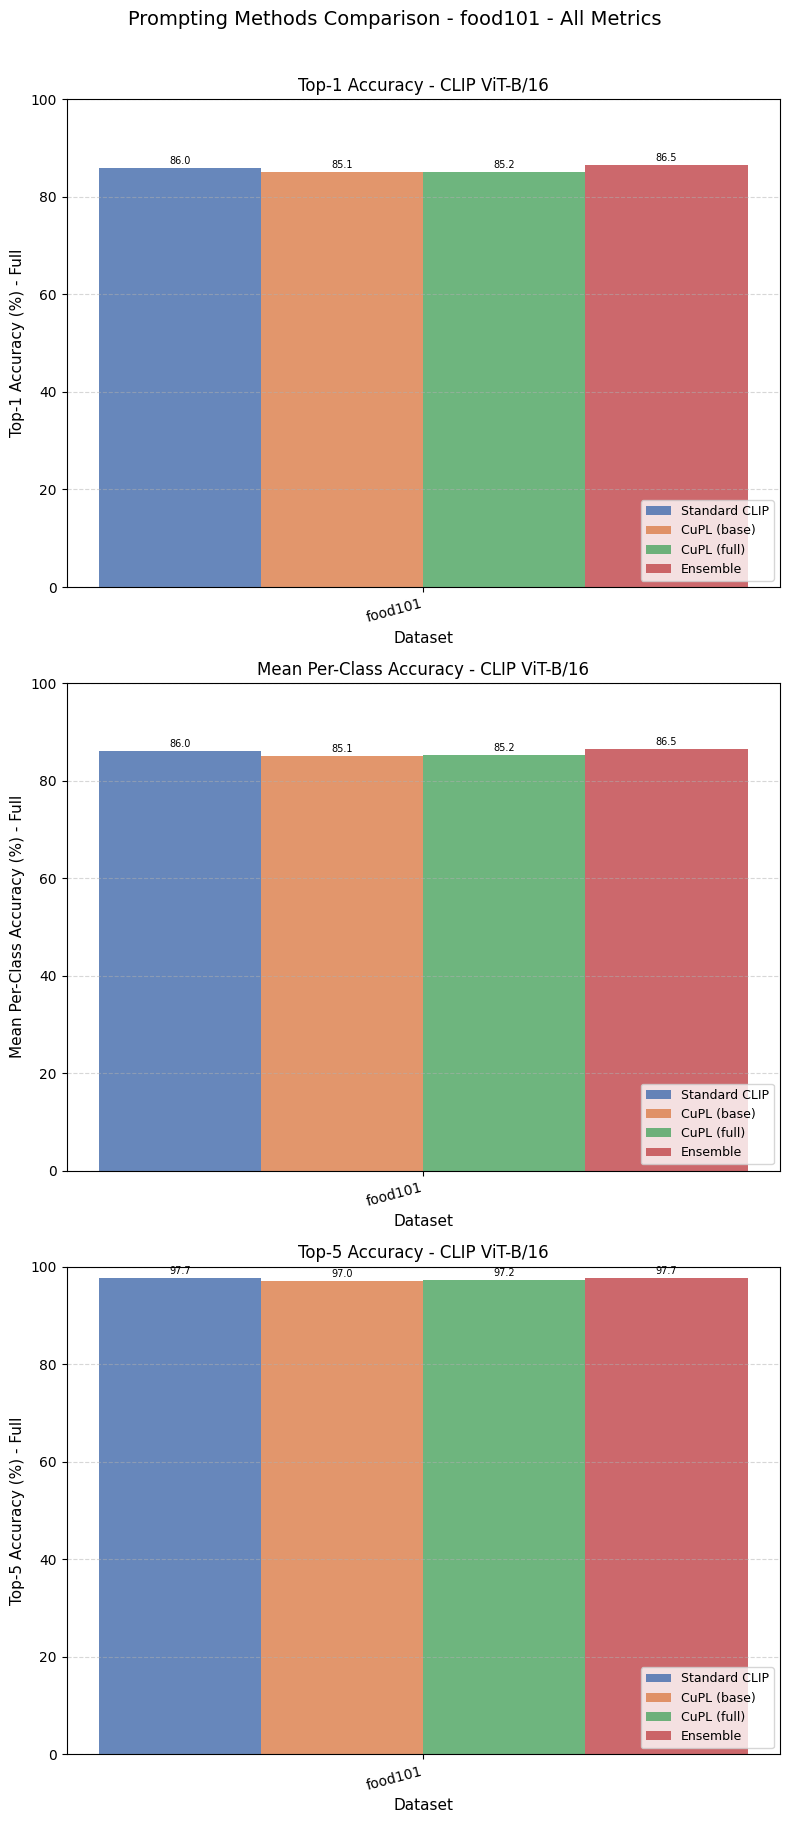

Saved: method_comparison_all_metrics.png


In [15]:
# Plot results for all 3 metrics
# Stores Top-1, Mean Per-Class, and Top-5 for all methods.
# Produces 3 comparison charts for each metric.

os.makedirs(f'{DATASET_NAME}', exist_ok=True)
RESULTS_FILE = Path(f'{DATASET_NAME}/{DATASET_NAME}_cupl_all_results.json')   # local disk

# Structure: {metric: {method: {dataset: value}}}
METHODS = ['Standard CLIP', 'CuPL (base)', 'CuPL (full)', 'Ensemble']
METRICS = ['top1', 'mpc', 'top5']

all_results = None
if RESULTS_FILE.exists():
    try:
        with open(RESULTS_FILE) as f:
            all_results = json.load(f)
        print(f'Loaded existing results: {list(all_results.get("top1", {}).get("Standard CLIP", {}).keys())}')
    except (json.JSONDecodeError, OSError) as e:
        print(f'Warning: could not load {RESULTS_FILE} ({e}) - starting fresh.')
        all_results = None
if all_results is None:
    all_results = {metric: {m: {} for m in METHODS} for metric in METRICS}
    print('Starting fresh results file.')

# Store all 3 metrics for current dataset
for metric, values in [
    ('top1', [std_full, base_full, cupl_full, ens_full]),
    ('mpc',  [std_mpc_full, base_mpc_full, full_mpc_full, ens_mpc_full]),
    ('top5', [std_top5_full, base_top5_full, full_top5_full, ens_top5_full]),
]:
    for method, val in zip(METHODS, values):
        if metric not in all_results:
            all_results[metric] = {m: {} for m in METHODS}
        if method not in all_results[metric]:
            all_results[metric][method] = {}
        all_results[metric][method][DATASET_NAME] = round(val, 2)

with open(RESULTS_FILE, 'w') as f:
    json.dump(all_results, f, indent=2)

all_datasets = list(all_results['top1']['Standard CLIP'].keys())
print(f'Saved. Datasets so far: {all_datasets}')

# Print summary tables
metric_labels = {'top1': 'Top-1 Accuracy', 'mpc': 'Mean Per-Class Accuracy', 'top5': 'Top-5 Accuracy'}
for metric, label in metric_labels.items():
    print(f'\n{label}:')
    print(f'  {"Method":<38}' + ''.join(f'  {d[:12]:>12}' for d in all_datasets))
    print(f'  {"-"*38}' + ''.join(['  ' + '-'*12] * len(all_datasets)))
    for method in METHODS:
        row = ''.join(f'  {all_results[metric][method].get(d, 0):>11.2f}%' for d in all_datasets)
        print(f'  {method:<38}{row}')

# 3 comparison charts - current dataset only
plot_dataset = [DATASET_NAME]
colours = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
x     = np.arange(len(plot_dataset))
width = 0.8 / len(METHODS)

fig, axes = plt.subplots(3, 1, figsize=(8, 18))

for ax, (metric, label) in zip(axes, metric_labels.items()):
    for i, method in enumerate(METHODS):
        vals = [all_results[metric][method].get(d, 0) for d in plot_dataset]
        offset = (i - len(METHODS) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=method, color=colours[i % len(colours)], alpha=0.85)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4, f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xlabel('Dataset', fontsize=11)
    ax.set_ylabel(f'{label} (%) - Full', fontsize=11)
    ax.set_title(f'{label} - CLIP ViT-B/16', fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(plot_dataset, rotation=15, ha='right')
    ax.legend(fontsize=9, loc='lower right'); ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'Prompting Methods Comparison - {DATASET_NAME} - All Metrics', fontsize=14, y=1.01)
plt.tight_layout()
os.makedirs(f'{DATASET_NAME}', exist_ok=True)
plt.savefig(f'{DATASET_NAME}/method_comparison_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: method_comparison_all_metrics.png')


## 10. Per-Class Accuracy Breakdown

Per-class accuracy on the **validation set** for Standard CLIP vs CuPL (full).
Shows which classes benefit from CuPL and which do not.

Computing per-class accuracy on validation set...

Class                            Standard     CuPL    Delta
------------------------------------------------------------
  apple pie                         76.0%    69.0%  ▼  7.0%
  baby back ribs                    83.5%    68.0%  ▼ 15.5%
  baklava                           81.0%    81.0%     0.0%
  beef carpaccio                    89.5%    87.5%  ▼  2.0%
  beef tartare                      77.0%    72.5%  ▼  4.5%
  beet salad                        77.0%    71.0%  ▼  6.0%
  beignets                          94.5%    93.5%  ▼  1.0%
  bibimbap                          92.5%    93.0%  ▲  0.5%
  bread pudding                     76.0%    80.5%  ▲  4.5%
  breakfast burrito                 85.0%    92.5%  ▲  7.5%
  bruschetta                        74.0%    68.0%  ▼  6.0%
  caesar salad                      98.0%    97.0%  ▼  1.0%
  cannoli                           93.5%    88.0%  ▼  5.5%
  caprese salad                     88.0%    86.

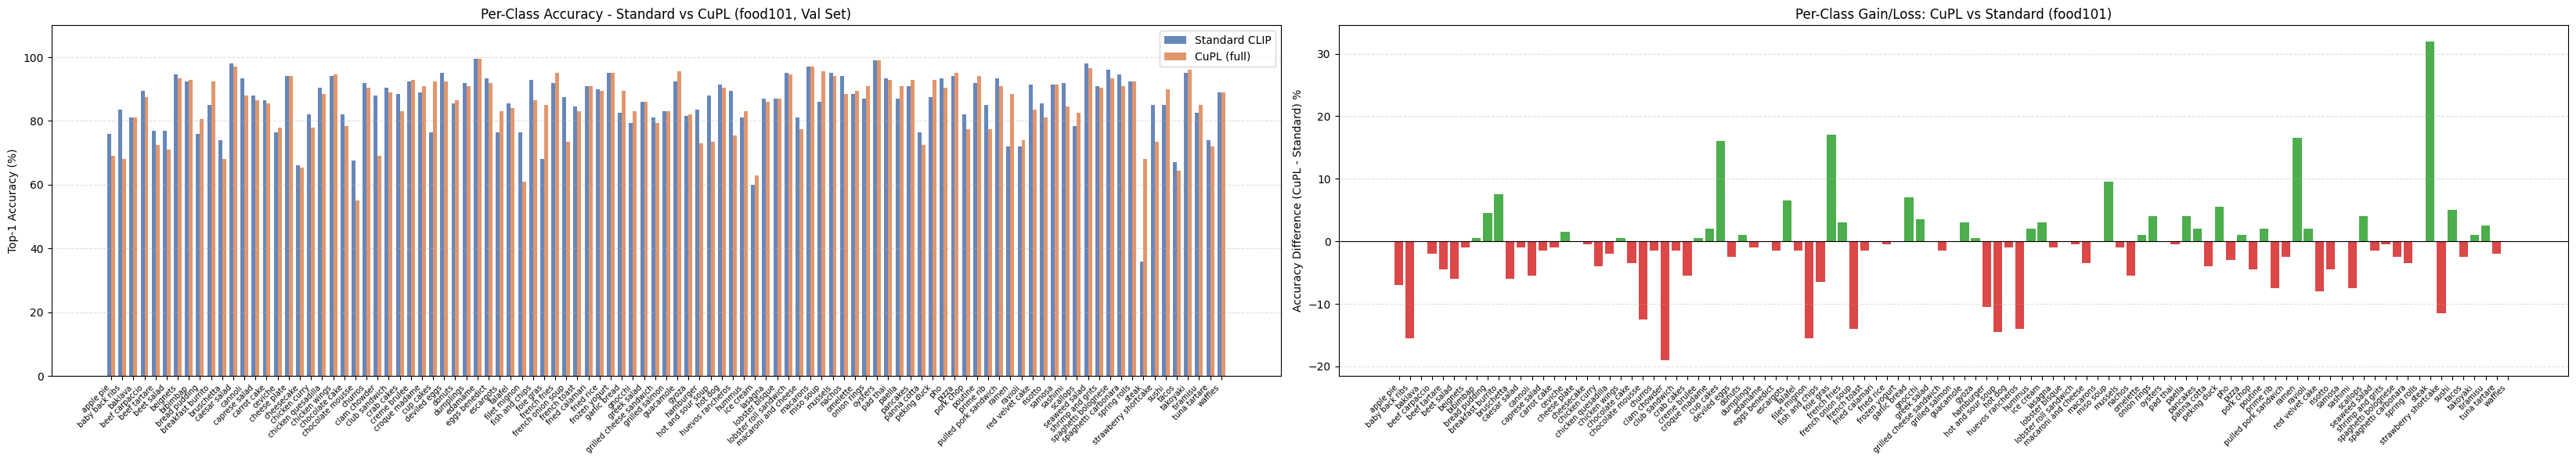

Saved: food101_per_class_accuracy.png


In [16]:
# Calculates accuracy individually separated per unique class to detect specific concept imbalances in the zero-shot pipeline.
def per_class_accuracy(loader, clip_model, text_features, classnames, device, covered_indices=None):
    """Return per-class top-1 accuracy as a dict {classname: accuracy}."""
    if covered_indices is not None:
        covered_set = set(covered_indices)
        idx_remap = {orig: new for new, orig in enumerate(covered_indices)}
        eval_names = [classnames[i] for i in covered_indices]
    else:
        covered_set = None
        idx_remap = None
        eval_names = classnames

    class_correct = {n: 0 for n in eval_names}
    class_total = {n: 0 for n in eval_names}

    clip_model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            if covered_set is not None:
                mask = torch.tensor([l.item() in covered_set for l in labels], dtype=torch.bool, device=device)
                if mask.sum() == 0:
                    continue
                images = images[mask]
                labels_orig = labels[mask]
                labels = torch.tensor([idx_remap[l.item()] for l in labels_orig], device=device)
            else:
                labels_orig = labels

            feats  = clip_model.encode_image(images)
            feats /= feats.norm(dim=-1, keepdim=True)
            logits = 100.0 * feats @ text_features.T
            preds  = logits.argmax(dim=-1)

            for pred, lbl_mapped, lbl_orig in zip(preds, labels, labels_orig if covered_set else labels):
                true_name = classnames[lbl_orig.item()]
                if true_name in class_total:
                    class_total[true_name]   += 1
                    class_correct[true_name] += (pred == lbl_mapped).item()

    return {n: 100.0 * class_correct[n] / class_total[n]
            if class_total[n] > 0 else 0.0
            for n in eval_names}


print('Computing per-class accuracy on validation set...')
baseline_per_class = per_class_accuracy(
    val_loader, clip_model, std_weights.T, CLASSES, device)
cupl_per_class = per_class_accuracy(
    val_loader, clip_model, cupl_features, CLASSES, device,
    covered_indices=covered_idx)

# Print table
print(f'\n{"Class":<30} {"Standard":>10} {"CuPL":>8} {"Delta":>8}')
print('-' * 60)
for cls in CLASSES:
    hc = baseline_per_class.get(cls, 0)
    cu = cupl_per_class.get(cls, 0)
    delta = cu - hc
    arrow = '\u25b2' if delta > 0 else ('\u25bc' if delta < 0 else ' ')
    print(f'  {cls:<28} {hc:>9.1f}%  {cu:>6.1f}%  {arrow}{abs(delta):>5.1f}%')

# Bar chart
hc_vals = [baseline_per_class.get(c, 0) for c in CLASSES]
cu_vals = [cupl_per_class.get(c, 0) for c in CLASSES]
deltas  = [cu - hc for hc, cu in zip(hc_vals, cu_vals)]
x = np.arange(len(CLASSES))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(max(16, len(CLASSES) // 3), 6))

ax = axes[0]
ax.bar(x - width/2, hc_vals, width, label='Standard CLIP', color='#4C72B0', alpha=0.85)
ax.bar(x + width/2, cu_vals, width, label='CuPL (full)', color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title(f'Per-Class Accuracy - Standard vs CuPL ({DATASET_NAME}, Val Set)')
ax.legend(); ax.set_ylim(0, 110); ax.grid(axis='y', ls='--', alpha=0.4)

ax = axes[1]
colours = ['#2ca02c' if d >= 0 else '#d62728' for d in deltas]
ax.bar(x, deltas, color=colours, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Accuracy Difference (CuPL - Standard) %')
ax.set_title(f'Per-Class Gain/Loss: CuPL vs Standard ({DATASET_NAME})')
ax.grid(axis='y', ls='--', alpha=0.4)

plt.tight_layout()
os.makedirs(f'{DATASET_NAME}', exist_ok=True)
plt.savefig(f'{DATASET_NAME}/{DATASET_NAME}_per_class_accuracy.png', dpi=150)
plt.show()
print(f'Saved: {DATASET_NAME}_per_class_accuracy.png')


In [17]:
# Per-class accuracy CSV
per_class_rows = []
for cls in CLASSES:
    per_class_rows.append({
        'class': cls,
        'standard': round(baseline_per_class.get(cls, 0), 2),
        'cupl_full': round(cupl_per_class.get(cls, 0), 2),
        'delta': round(cupl_per_class.get(cls, 0) - baseline_per_class.get(cls, 0), 2),
    })

per_class_csv = CSV_DIR / f'{DATASET_NAME}_per_class.csv'
pd.DataFrame(per_class_rows).to_csv(per_class_csv, index=False)
print(f'Saved: {per_class_csv}')

df_pc = pd.DataFrame(per_class_rows).sort_values('delta', ascending=False)
print(f'\nTop 5 gains:')
print(df_pc.head(5).to_string(index=False))
print(f'\nTop 5 losses:')
print(df_pc.tail(5).to_string(index=False))


Saved: food101_cupl_prompts\food101_per_class.csv

Top 5 gains:
    class  standard  cupl_full  delta
    steak      36.0       68.0   32.0
foie gras      68.0       85.0   17.0
    ramen      72.0       88.5   16.5
cup cakes      76.5       92.5   16.0
miso soup      86.0       95.5    9.5

Top 5 losses:
            class  standard  cupl_full  delta
 huevos rancheros      89.5       75.5  -14.0
hot and sour soup      88.0       73.5  -14.5
   baby back ribs      83.5       68.0  -15.5
     filet mignon      76.5       61.0  -15.5
     clam chowder      88.0       69.0  -19.0


## 11. Text-to-Image Attention Maps (Occlusion Sensitivity)

We use **occlusion sensitivity** to visualise which image regions the model
focuses on under *handcrafted* vs *CuPL* prompts - analogous to Figure 5 of
the CuPL paper. A grey patch is slid over the image; a large drop in class
probability signals that region was important for classification.

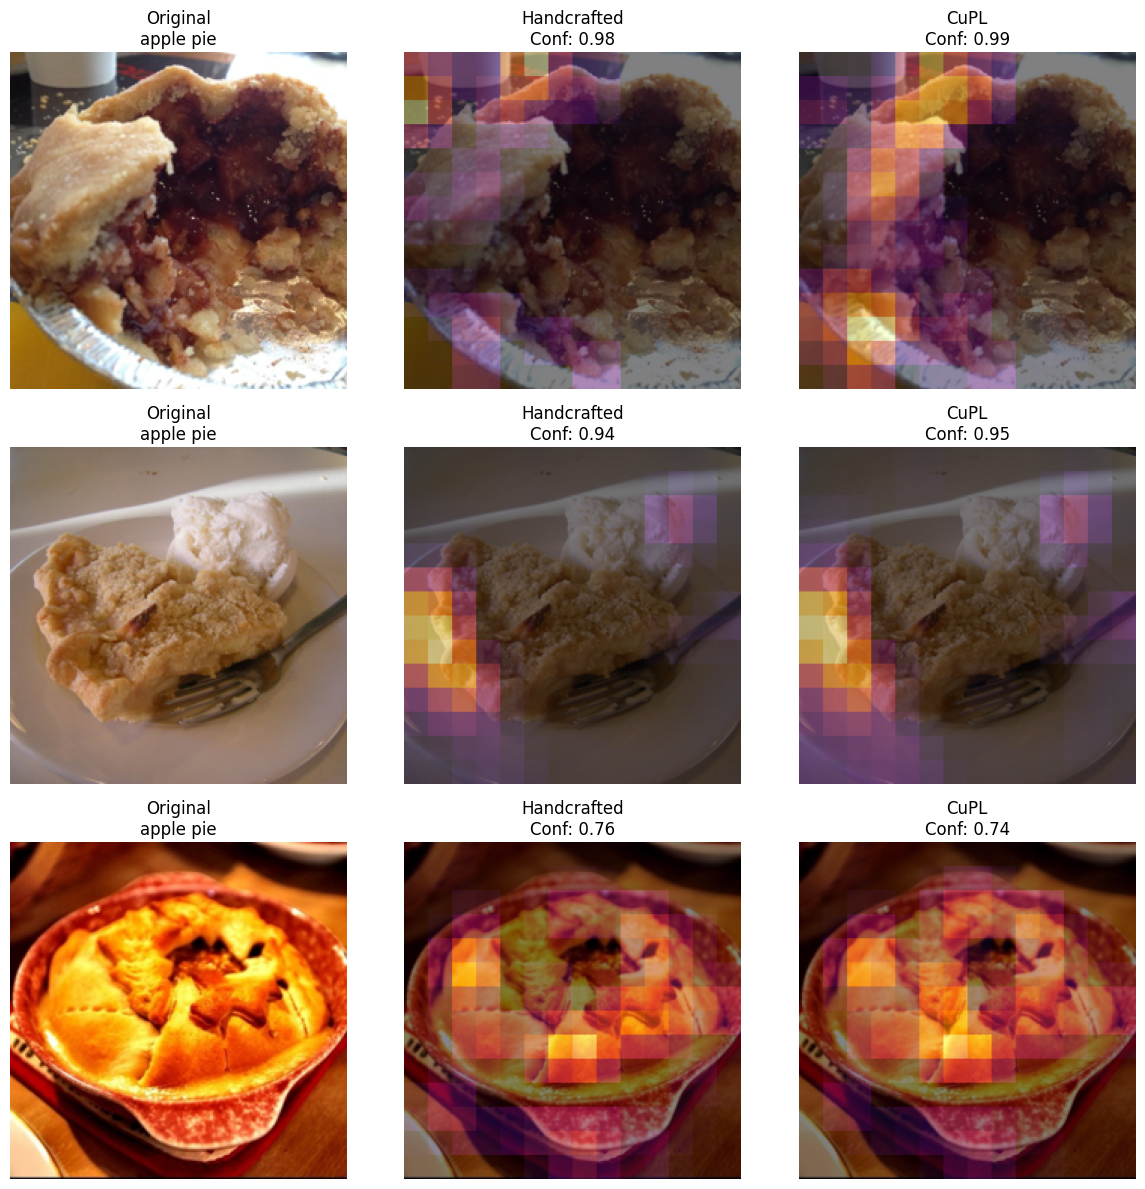

In [18]:
# Uses an occlusion sensitivity technique. 
# We systematically occlude chunks of the initial image using sliding patches and observe the drop in logits to trace visual-verbal attention gaps.
def generate_occlusion_map(img_tensor, text_feats, cls_idx, patch_size=32, stride=16):
    """Return (normalised heatmap, base class probability) for one image."""
    _, _, H, W = img_tensor.shape
    heatmap = np.zeros((H, W))
    counts = np.zeros((H, W))

    with torch.no_grad():
        image_features  = clip_model.encode_image(img_tensor)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        base_prob = (100.0 * image_features @ text_feats.T).softmax(-1)[0, cls_idx].item()

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occ = img_tensor.clone()
            occ[0, :, y:y+patch_size, x:x+patch_size] = 0.0
            with torch.no_grad():
                f = clip_model.encode_image(occ)
                f /= f.norm(dim=-1, keepdim=True)
                p = (100.0 * f @ text_feats.T).softmax(-1)[0, cls_idx].item()
            imp = max(0, base_prob - p)
            heatmap[y:y+patch_size, x:x+patch_size] += imp
            counts[y:y+patch_size, x:x+patch_size] += 1

    heatmap /= (counts + 1e-8)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap, base_prob


def denorm(tensor):
    """Reverse CLIP normalisation for visualisation."""
    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3, 1, 1).to(device)
    std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1).to(device)
    return ((tensor * std + mean).clamp(0, 1)[0].cpu().permute(1, 2, 0).numpy())


# Grab 3 sample images from the full loader
samples = []
for imgs, lbls in full_loader:
    for offset in [0, 10, 20]:
        if offset < len(imgs):
            samples.append((imgs[offset:offset+1], lbls[offset].item()))
    break

# Single-template handcrafted features (C x D) - use CLASSES for text encoding
hc_feats = zeroshot_classifier(CLASSES, ["a photo of a {}."], clip_model, device).T  # (C, D)

fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4 * len(samples)))
for i, (img_t, lbl_idx) in enumerate(samples):
    img_t = img_t.to(device)
    orig = denorm(img_t)
    cupl_lbl = covered_idx.index(lbl_idx) if lbl_idx in covered_idx else -1

    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f'Original\n{CLASSES[lbl_idx]}')
    axes[i, 0].axis('off')

    hm_hc, sc_hc = generate_occlusion_map(img_t, hc_feats, lbl_idx)
    axes[i, 1].imshow(orig)
    axes[i, 1].imshow(hm_hc, cmap='inferno', alpha=0.5)
    axes[i, 1].set_title(f'Handcrafted\nConf: {sc_hc:.2f}')
    axes[i, 1].axis('off')

    if cupl_lbl != -1:
        hm_cu, sc_cu = generate_occlusion_map(img_t, cupl_features, cupl_lbl)
        axes[i, 2].imshow(orig)
        axes[i, 2].imshow(hm_cu, cmap='inferno', alpha=0.5)
        axes[i, 2].set_title(f'CuPL\nConf: {sc_cu:.2f}')
    else:
        axes[i, 2].set_title('CuPL: No prompts for this class')
    axes[i, 2].axis('off')

plt.tight_layout()
os.makedirs(f'{DATASET_NAME}', exist_ok=True)
plt.savefig(f'{DATASET_NAME}/attention_comparison.png', dpi=150)
plt.show()


## 12. Hyperparameter Ablations - Prompt Diversity & Number of Templates

CuPL paper Figure 4 presents two ablations which we both reproduce:

- **Figure 4 (top) - Effect of number of LLM-prompt templates:** Varies the number of hand-written LLM-prompt templates from 1 -> N (all available), holding generations per template fixed at 10. Shows CuPL outperforms Standard CLIP even with just 1 hand-written template.

- **Figure 4 (bottom) - Effect of image-prompt diversity (N):** Varies the number of image-prompts generated per LLM-prompt template (N = 1, 2, 5, 10), holding templates fixed. Even at N=5 (25 total prompts) CuPL outperforms the Standard CLIP baseline which uses 80 image-prompts.

Pre-computing image features (done once for all ablation steps)...
Image features ready - full: 101000, val: 20200, test: 20200

Dataset: food101 | Templates: 3
Built features for 101/101 classes.
1/3 templates (10 prompts/class) val=84.95%  test=84.24%  full=84.64%
Built features for 101/101 classes.
2/3 templates (20 prompts/class) val=85.10%  test=84.44%  full=84.83%
Built features for 101/101 classes.
3/3 templates (30 prompts/class) val=85.42%  test=84.79%  full=85.15%


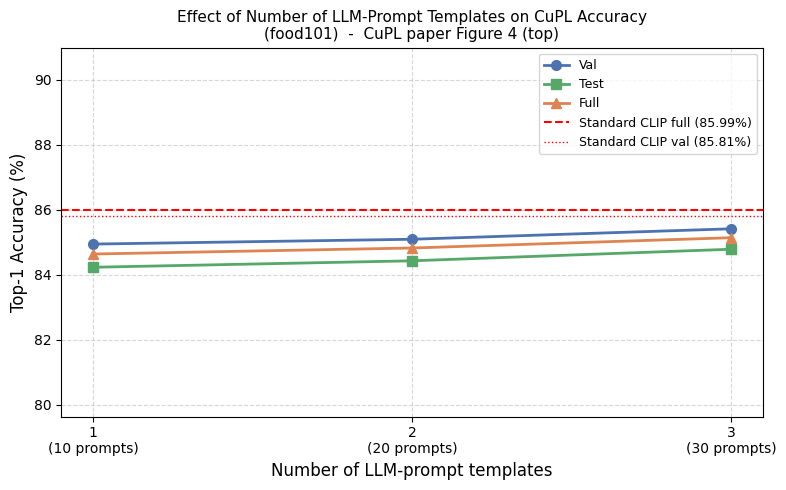

Saved: food101_ablation_n_templates.png


In [19]:
# Pre-compute image features ONCE - reuse for all template counts
print('Pre-computing image features (done once for all ablation steps)...')
all_img_feats = []
all_img_labels = []

clip_model.eval()
with torch.no_grad():
    for images, labels in full_loader:
        images = images.to(device)
        feats = clip_model.encode_image(images)
        feats /= feats.norm(dim=-1, keepdim=True)
        all_img_feats.append(feats.cpu())
        all_img_labels.append(labels)

all_img_feats = torch.cat(all_img_feats,  dim=0)  # (N, D)
all_img_labels = torch.cat(all_img_labels, dim=0)  # (N,)

# Recreate val/test splits from the full indices
# (same generator and seed as Cell 6)
total = len(full_dataset)
train_size = int(0.6 * total)
val_size = int(0.2 * total)
test_size = total - train_size - val_size
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(total, generator=generator)
val_idx = indices[train_size: train_size + val_size]
test_idx = indices[train_size + val_size:]

val_feats = all_img_feats[val_idx];    val_labels = all_img_labels[val_idx]
test_feats = all_img_feats[test_idx];  test_labels = all_img_labels[test_idx]
full_feats = all_img_feats;            full_labels = all_img_labels
print(f'Image features ready - full: {len(full_feats)}, val: {len(val_feats)}, test: {len(test_feats)}')


def fast_eval(img_feats, img_labels, text_features, covered_indices=None):
    """Evaluate accuracy from pre-computed image features - no DataLoader needed."""
    if covered_indices is not None:
        covered_set = set(covered_indices)
        idx_remap = {orig: new for new, orig in enumerate(covered_indices)}
        mask = torch.tensor([l.item() in covered_set for l in img_labels])
        img_feats = img_feats[mask]
        img_labels = torch.tensor([idx_remap[l.item()] for l in img_labels[mask]])

    logits  = 100.0 * img_feats.to(device) @ text_features.T
    preds = logits.argmax(dim=-1).cpu()
    correct = (preds == img_labels).sum().item()
    return 100.0 * correct / len(img_labels)


# Ablation loop - text features only, no image re-encoding
n_templates_total = len(CUPL_FULL_TEMPLATES)
template_range = list(range(1, n_templates_total + 1))

print(f'\nDataset: {DATASET_NAME} | Templates: {n_templates_total}')

if n_templates_total < 2:
    print(f'Only {n_templates_total} template - need at least 2. Run on EuroSAT (5 templates).')
else:
    template_val_accs = []
    template_test_accs = []
    template_full_accs = []

    for n_t in template_range:
        n_prompts = n_t * N_PER_TEMPLATE
        subset = {cls: prompts[:n_prompts] for cls, prompts in full_saved_prompts.items()}

        feats, cov = build_cupl_features(subset, CLASSES)
        v = fast_eval(val_feats,  val_labels,  feats, covered_indices=cov)
        t = fast_eval(test_feats, test_labels, feats, covered_indices=cov)
        f = fast_eval(full_feats, full_labels, feats, covered_indices=cov)

        template_val_accs.append(v)
        template_test_accs.append(t)
        template_full_accs.append(f)
        print(f'{n_t}/{n_templates_total} templates ({n_prompts} prompts/class) val={v:.2f}%  test={t:.2f}%  full={f:.2f}%')

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(template_range, template_val_accs,  marker='o', color='#4C72B0', lw=2, ms=7, label='Val')
    ax.plot(template_range, template_test_accs, marker='s', color='#55A868', lw=2, ms=7, label='Test')
    ax.plot(template_range, template_full_accs, marker='^', color='#DD8452', lw=2, ms=7, label='Full')
    ax.axhline(std_full, color='red', ls='--', lw=1.5, label=f'Standard CLIP full ({std_full:.2f}%)')
    ax.axhline(std_val,  color='red', ls=':',  lw=1.0, label=f'Standard CLIP val ({std_val:.2f}%)')
    ax.set_xlabel('Number of LLM-prompt templates', fontsize=12)
    ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
    ax.set_title(f'Effect of Number of LLM-Prompt Templates on CuPL Accuracy\n({DATASET_NAME})  -  CuPL paper Figure 4 (top)', fontsize=11)
    ax.set_xticks(template_range)
    ax.set_xticklabels([f'{n}\n({n*N_PER_TEMPLATE} prompts)' for n in template_range])
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)
    ax.set_ylim(max(0, min(template_full_accs + [std_full]) - 5), max(template_full_accs + [std_full]) + 5)
    plt.tight_layout()
    os.makedirs(f'{DATASET_NAME}', exist_ok=True)
    plt.savefig(f'{DATASET_NAME}/{DATASET_NAME}_ablation_n_templates.png', dpi=150)
    plt.show()
    print(f'Saved: {DATASET_NAME}_ablation_n_templates.png')


N=1  (3 prompts/class)  Built features for 101/101 classes.
N=2  (6 prompts/class)  Built features for 101/101 classes.
N=5  (15 prompts/class)  Built features for 101/101 classes.
N=10  (30 prompts/class)  Built features for 101/101 classes.

Ablation results: {1: 83.15445544554456, 2: 84.11782178217821, 5: 84.96138613861386, 10: 85.14653465346535}


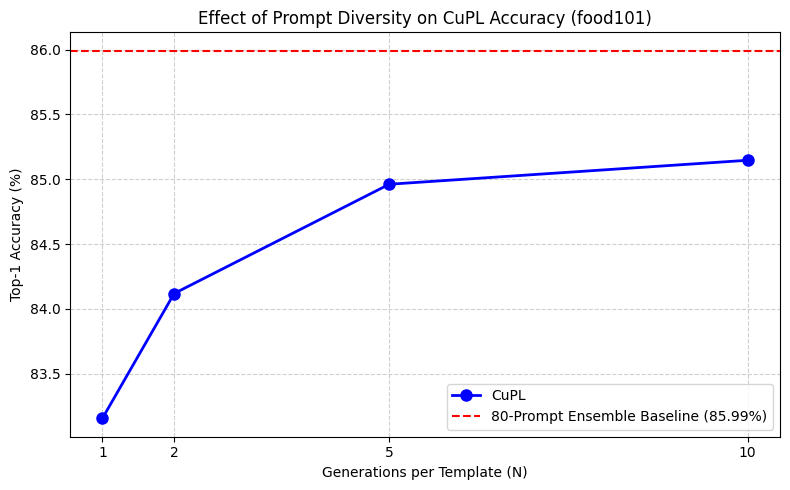

In [20]:
N_values, ablation_accs = [1, 2, 5, 10], []

for n in N_values:
    if n > N_PER_TEMPLATE:
        continue
    # Build a subset: take only the first n prompts from each template block
    subset = {}
    for cls, prompts in full_saved_prompts.items():
        s = []
        for i in range(0, len(prompts), N_PER_TEMPLATE):
            s.extend(prompts[i:i + n])
        subset[cls] = s

    n_total = len(next(iter(subset.values())))
    print(f'N={n}  ({n_total} prompts/class)', end='  ')
    feats, cov = build_cupl_features(subset, CLASSES)
    acc = evaluate_with_features(full_loader, clip_model, feats, device, covered_indices=cov)
    ablation_accs.append(acc)

print(f'\nAblation results: {dict(zip(N_values[:len(ablation_accs)], ablation_accs))}')

plt.figure(figsize=(8, 5))
plt.plot(N_values[:len(ablation_accs)], ablation_accs, marker='o', color='blue', lw=2, ms=8, label='CuPL')
plt.axhline(baseline_acc_full, color='red', ls='--', label=f'80-Prompt Ensemble Baseline ({baseline_acc_full:.2f}%)')
plt.title(f'Effect of Prompt Diversity on CuPL Accuracy ({DATASET_NAME})')
plt.xlabel('Generations per Template (N)')
plt.ylabel('Top-1 Accuracy (%)')
plt.xticks(N_values[:len(ablation_accs)])
plt.grid(True, ls='--', alpha=0.6)
plt.legend()
plt.tight_layout()
os.makedirs(f'{DATASET_NAME}', exist_ok=True)
plt.savefig(f'{DATASET_NAME}/ablation_N.png', dpi=150)
plt.show()


---

## 13. Embedding Space Visualisation - PCA, t-SNE, UMAP
*(Extra credit - dimensionality reduction of text and image features)*

CLIP produces 512-dimensional embeddings. We compress these to 2D using three
techniques to visualise how each prompting method structures the embedding space:

- **PCA** - linear, fast, shows global variance structure
- **t-SNE** - non-linear, preserves local neighbourhood, good for cluster separation
- **UMAP** - non-linear, preserves both local and global structure, fastest of the two non-linear methods

For each method we plot:
1. **Text embeddings only** - one point per class per prompting method (Standard vs CuPL)
2. **Image + Text embeddings** - image features coloured by true class, text anchors shown as stars
   - good alignment means image clusters overlap with their correct text anchor

In [21]:
!pip install umap-learn --quiet

Text embeddings: std=(101, 512), full=(101, 512), base=(101, 512)
Image subsample: 3030 images | Text embeddings: 101 classes x 3 methods
Fitting PCA...


C:\Users\lambr\AppData\Local\Temp\ipykernel_12676\1474796663.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_cls)


  PCA (text)  explained variance: 15.6%
  PCA (image) explained variance: 11.9%
Fitting t-SNE (this may take ~1-2 min)...
Fitting UMAP...


C:\Users\lambr\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\lambr\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


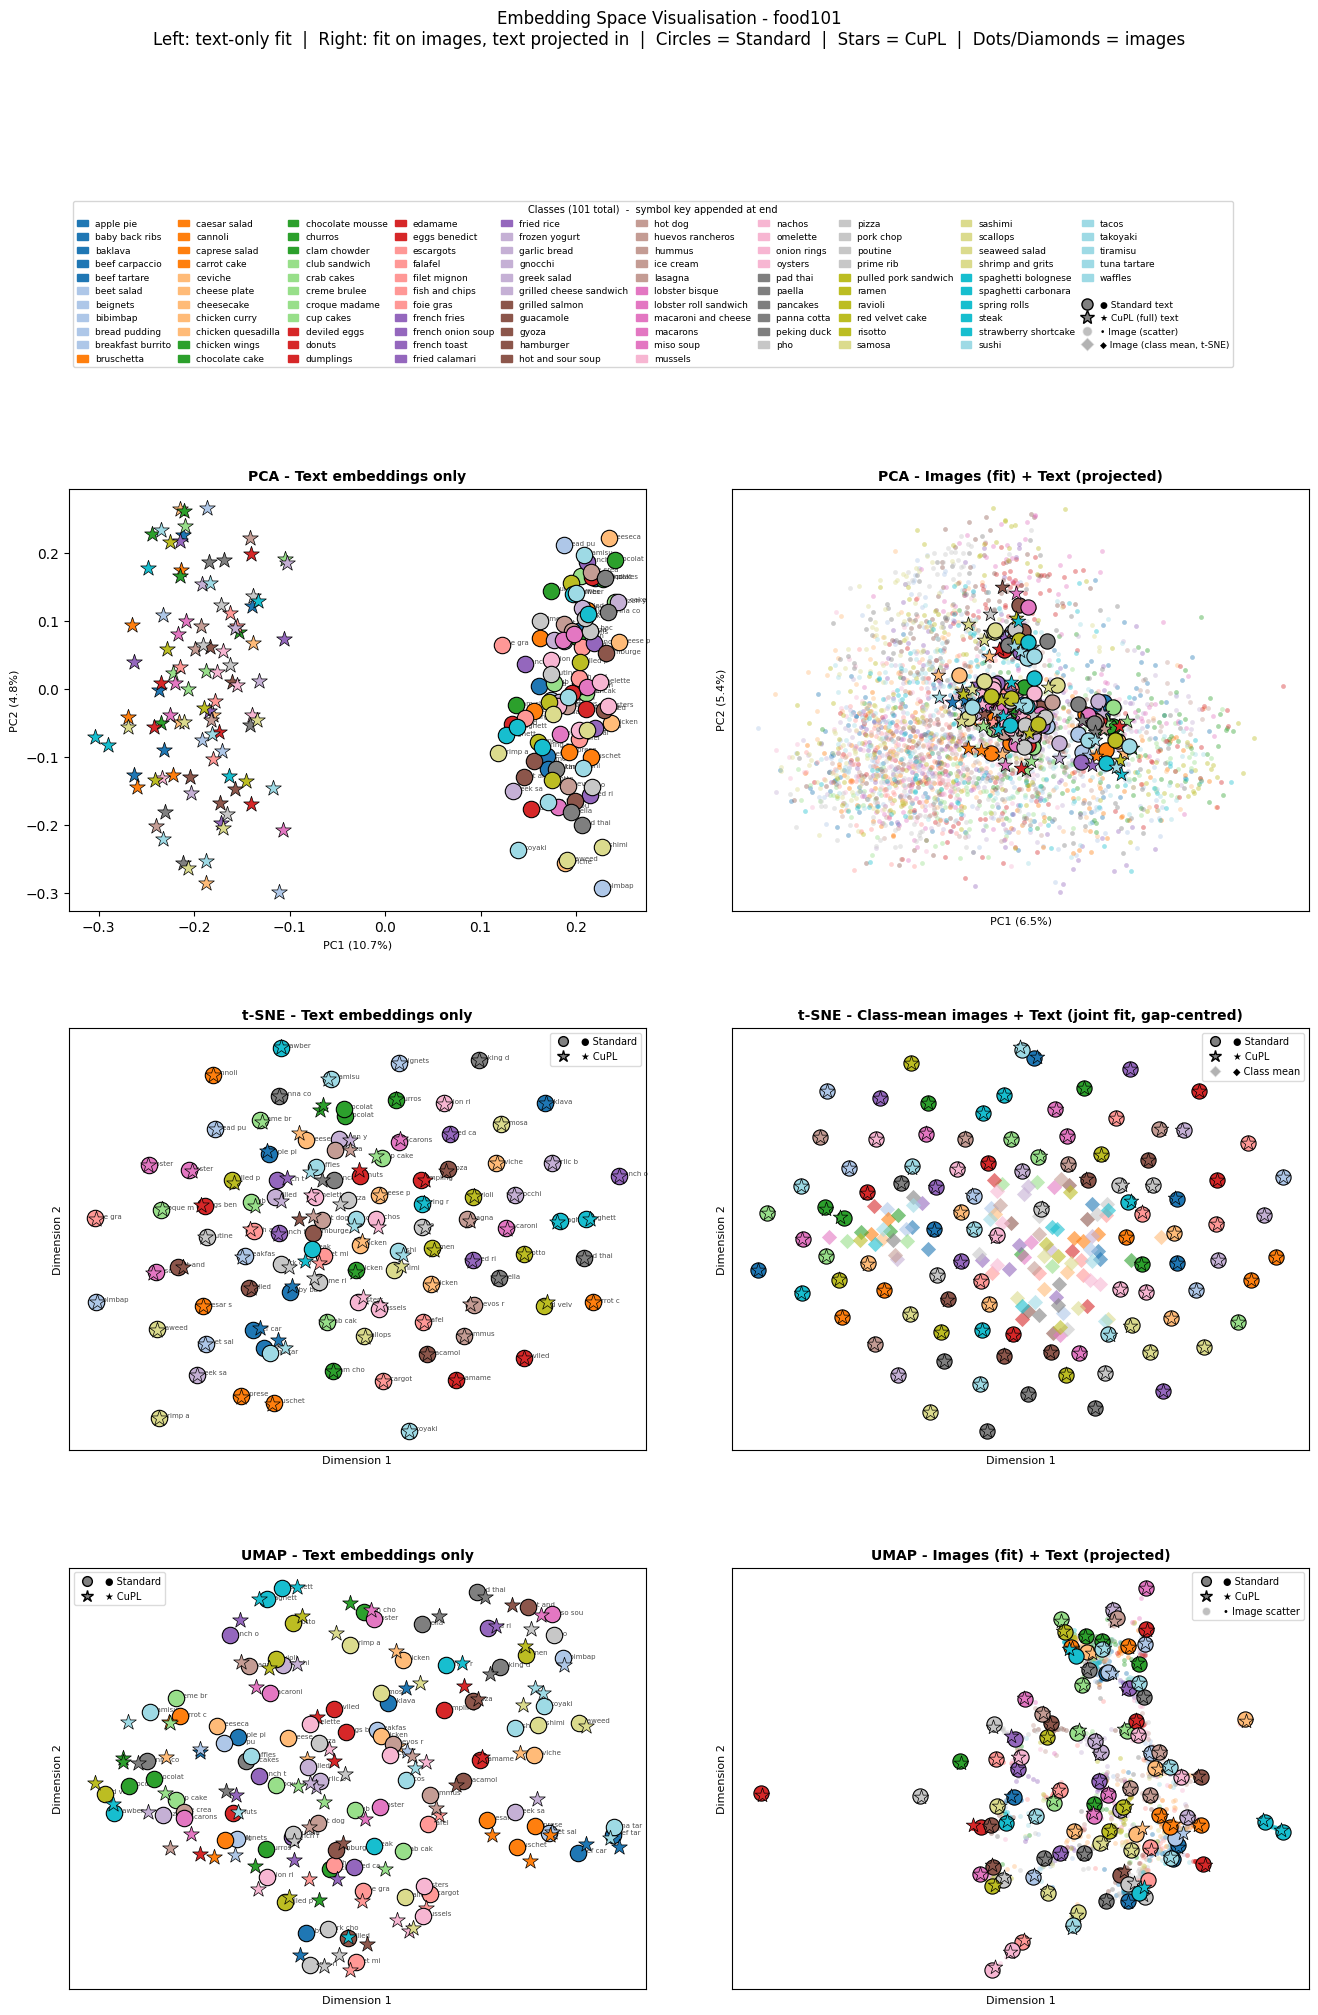

Saved: food101_embedding_visualisation.png

Plotting text embedding comparison across all 3 prompting methods...


C:\Users\lambr\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


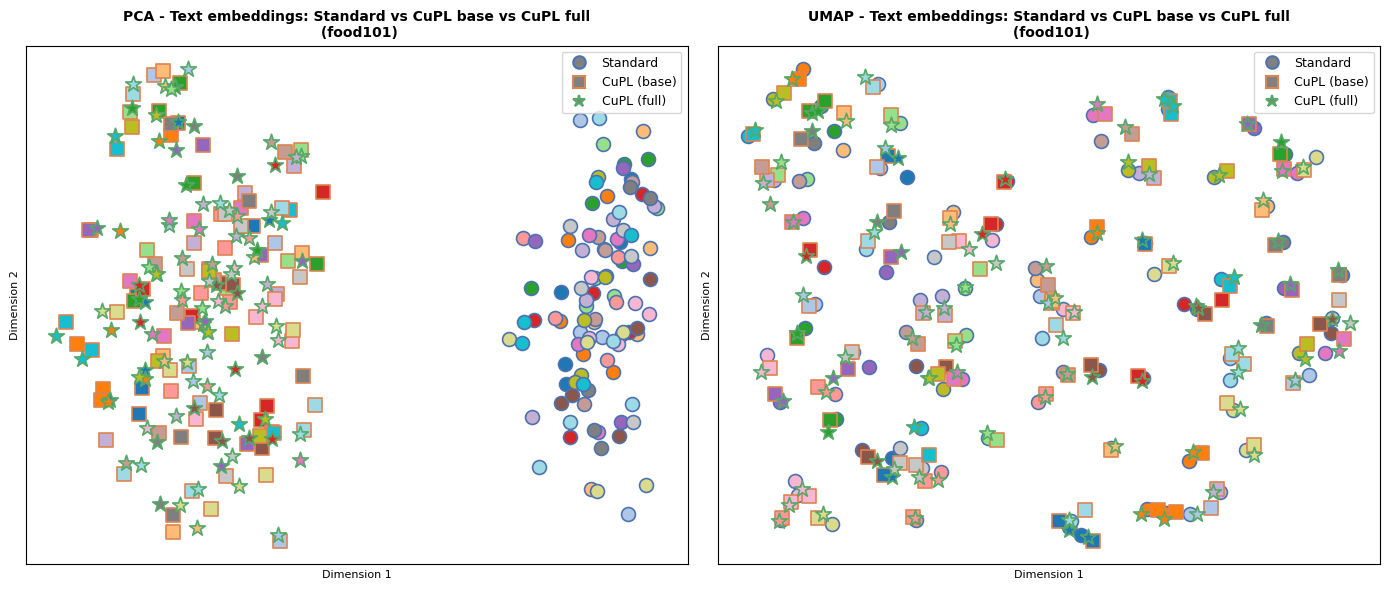

Saved: food101_text_embedding_methods.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Collect text embeddings for each prompting method
# std_weights shape: (D, C) - transpose to (C, D)
text_std = std_weights.T.cpu().numpy()   # Standard CLIP - always (C, D)

# cupl_features / base_features only cover classes that had prompts generated.
# Expand both to full (C, D) arrays so cls_idx always maps to CLASSES[cls_idx].
# Missing classes get a zero vector - guarded against in all scatter loops below.
_D = text_std.shape[1]
_n = len(CLASSES)

text_full = np.zeros((_n, _D), dtype=np.float32)
for new_i, orig_i in enumerate(covered_idx):
    text_full[orig_i] = cupl_features[new_i].cpu().numpy()

text_base = np.zeros((_n, _D), dtype=np.float32)
for new_i, orig_i in enumerate(base_covered_idx):
    text_base[orig_i] = base_features[new_i].cpu().numpy()

n_missing_full = _n - len(covered_idx)
n_missing_base = _n - len(base_covered_idx)
if n_missing_full > 0:
    print(f'WARNING: {n_missing_full} classes have no CuPL (full) prompts - skipped in plots.')
if n_missing_base > 0:
    print(f'WARNING: {n_missing_base} classes have no CuPL (base) prompts - skipped in plots.')
print(f'Text embeddings: std={text_std.shape}, full={text_full.shape}, base={text_base.shape}')

# Collect image embeddings (subsample for speed)
print('Collecting image embeddings...')
img_feats_list = []
img_labels_list = []

clip_model.eval()
with torch.no_grad():
    for images, labels in full_loader:
        images = images.to(device)
        feats = clip_model.encode_image(images)
        feats /= feats.norm(dim=-1, keepdim=True)
        img_feats_list.append(feats.cpu().numpy())
        img_labels_list.append(labels.numpy())

img_feats = np.concatenate(img_feats_list,  axis=0)   # (N, D)
img_labels = np.concatenate(img_labels_list, axis=0)   # (N,)

# Subsample images for speed - 30 per class max
np.random.seed(42)
keep_idx = []
for cls_idx in range(len(CLASSES)):
    idx = np.where(img_labels == cls_idx)[0]
    keep_idx.extend(np.random.choice(idx, min(30, len(idx)), replace=False))
img_feats_sub  = img_feats[keep_idx]
img_labels_sub = img_labels[keep_idx]

n_img = len(img_feats_sub)
n_cls = len(CLASSES)

print(f'Image subsample: {n_img} images | Text embeddings: {n_cls} classes x 3 methods')

# Colour palette - one colour per class
cmap = plt.cm.get_cmap('tab20', n_cls)
colors = [cmap(i) for i in range(n_cls)]

# NaN-safe per-class mean image embedding (used for t-SNE right column)
_means = []
for i in range(n_cls):
    cls_feats = img_feats_sub[img_labels_sub == i]
    _means.append(cls_feats.mean(0) if len(cls_feats) > 0 else np.zeros(_D))
img_class_means = np.stack(_means)   # (C, D)

# Fitting strategy
# Left column  (text only)  : fit_transform on text only - slice for std/full
# Right column (image+text) : fit on IMAGE embeddings, project text via .transform()
#                             avoids CLIP modality gap dominating the projection.
#                             t-SNE: no .transform() - joint fit on class means + text.
#                             Modality gap is removed by mean-centering each modality
#                             before the joint fit so t-SNE sees alignment structure,
#                             not the raw cross-modal offset.
# Zero vectors (missing CuPL classes) excluded from fitting; guarded in plotting.

# PCA
print('Fitting PCA...')
valid_full  = text_full[np.any(text_full, axis=1)]   # exclude zero vectors
txt_for_pca = np.concatenate([text_std, valid_full])

pca_txt = PCA(n_components=2, random_state=42).fit(txt_for_pca)
pca_std = pca_txt.transform(text_std)
pca_full = pca_txt.transform(text_full)   # zeros project to a fixed point; guarded below

pca_img_fit  = PCA(n_components=2, random_state=42).fit(img_feats_sub)
pca_img = pca_img_fit.transform(img_feats_sub)
pca_std_proj = pca_img_fit.transform(text_std)
pca_full_proj= pca_img_fit.transform(text_full)
print(f'  PCA (text)  explained variance: {pca_txt.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  PCA (image) explained variance: {pca_img_fit.explained_variance_ratio_.sum()*100:.1f}%')

# t-SNE
print('Fitting t-SNE (this may take ~1-2 min)...')
perp = max(2, min(30, n_cls // 2))   # stable even for small class counts

tsne_txt_all = TSNE(n_components=2, perplexity=perp, random_state=42,
                    max_iter=1000, learning_rate='auto', init='pca').fit_transform(
                    np.concatenate([text_std, valid_full]))
n_valid_full = len(valid_full)
tsne_std = tsne_txt_all[:n_cls]           # all std classes (always C)
tsne_full_valid = tsne_txt_all[n_cls:]        # only covered classes

# Build full-size tsne_full with zeros for missing classes
tsne_full = np.zeros((n_cls, 2), dtype=np.float32)
covered_mask = np.any(text_full, axis=1)
tsne_full[covered_mask] = tsne_full_valid

# Right column: class-mean images + text in a joint fit.
# FIX: mean-centre each modality independently before concatenating so t-SNE
# focuses on alignment quality rather than the CLIP modality gap (the systematic
# offset between the image and text embedding subspaces).
valid_full_for_tsne = text_full[covered_mask]

img_centered = img_class_means - img_class_means.mean(axis=0)
txt_std_centered = text_std - text_std.mean(axis=0)
txt_full_centered = valid_full_for_tsne - valid_full_for_tsne.mean(axis=0)

tsne_joint = TSNE(n_components=2, perplexity=perp, random_state=42,
                      max_iter=1000, learning_rate='auto', init='pca').fit_transform(
                      np.concatenate([img_centered, txt_std_centered, txt_full_centered]))
tsne_img_means = tsne_joint[:n_cls]
tsne_std_proj = tsne_joint[n_cls:2*n_cls]
tsne_full_valid2 = tsne_joint[2*n_cls:]

tsne_full_proj = np.zeros((n_cls, 2), dtype=np.float32)
tsne_full_proj[covered_mask] = tsne_full_valid2

# UMAP
print('Fitting UMAP...')
n_nb = min(15, n_cls - 1)

# Left: fit_transform on combined text then slice - consistent positions
umap_txt_all = umap.UMAP(n_components=2, n_neighbors=n_nb, min_dist=0.1, random_state=42).fit_transform(np.concatenate([text_std, valid_full]))
tsne_std_umap = umap_txt_all[:n_cls]   # naming kept as umap below
umap_std = umap_txt_all[:n_cls]
umap_full_valid = umap_txt_all[n_cls:]

umap_full = np.zeros((n_cls, 2), dtype=np.float32)
umap_full[covered_mask] = umap_full_valid

# Right: fit_transform on images, then project text
umap_img_fit = umap.UMAP(n_components=2, n_neighbors=n_nb, min_dist=0.1, random_state=42)
umap_img = umap_img_fit.fit_transform(img_feats_sub)
umap_std_proj = umap_img_fit.transform(text_std)
umap_full_proj = umap_img_fit.transform(text_full)
print('Done.')


# Helper: plot image scatter + text anchors
def plot_embedding(ax, img_2d, txt_std_2d, txt_cupl_2d, img_lbl, title, show_legend=False, img_is_means=False):
    """Plot image points + text anchors for Standard vs CuPL."""
    if img_is_means:
        for cls_idx in range(n_cls):
            ax.scatter(img_2d[cls_idx, 0], img_2d[cls_idx, 1], color=colors[cls_idx], s=60, alpha=0.6, marker='D', linewidths=0)
    else:
        for cls_idx in range(n_cls):
            mask = img_lbl == cls_idx
            if mask.sum() == 0:
                continue
            ax.scatter(img_2d[mask, 0], img_2d[mask, 1], color=colors[cls_idx], s=12, alpha=0.4, linewidths=0)

    for cls_idx in range(n_cls):
        ax.scatter(txt_std_2d[cls_idx, 0], txt_std_2d[cls_idx, 1], color=colors[cls_idx], s=120, marker='o', edgecolors='black', linewidths=0.8, zorder=5)
        if np.any(txt_cupl_2d[cls_idx]):   # skip missing CuPL classes
            ax.scatter(txt_cupl_2d[cls_idx, 0], txt_cupl_2d[cls_idx, 1], color=colors[cls_idx], s=120, marker='*', edgecolors='black', linewidths=0.5, zorder=5)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

    if show_legend:
        img_marker = 'D' if img_is_means else 'o'
        img_label  = 'Image (class mean)' if img_is_means else 'Image features'
        legend_elements = (
            [mpatches.Patch(color=colors[i], label=CLASSES[i]) for i in range(n_cls)] +
            [
                plt.Line2D([0],[0], marker=img_marker, color='w', markerfacecolor='grey', markersize=7, label=img_label),
                plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=8, markeredgecolor='black', label='Text - Standard'),
                plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='grey', markersize=10, markeredgecolor='black', label='Text - CuPL')
            ]
        )
        ax.legend(handles=legend_elements, fontsize=6, loc='lower right', ncol=2, framealpha=0.8)


# Plot 4-row grid: Row 0 = legend, Rows 1-3 = PCA / t-SNE / UMAP
fig = plt.figure(figsize=(16, 22))
gs  = fig.add_gridspec(4, 2, height_ratios=[0.18, 1, 1, 1], hspace=0.35, wspace=0.15)

fig.suptitle(
    f'Embedding Space Visualisation - {DATASET_NAME}\n'
    'Left: text-only fit  |  Right: fit on images, text projected in  |  '
    'Circles = Standard  |  Stars = CuPL  |  Dots/Diamonds = images',
    fontsize=12, y=1.01
)

# Row 0: unified legend - class colour patches + marker-type entries
ax_leg = fig.add_subplot(gs[0, :])
ax_leg.set_axis_off()

marker_separator = [mpatches.Patch(color='none', label='')]   # blank spacer
marker_handles = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=8, markeredgecolor='black', label='● Standard text'),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='grey', markersize=10, markeredgecolor='black', label='★ CuPL (full) text'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=7, alpha=0.5, label='• Image (scatter)'),
    plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='grey', markersize=7, alpha=0.6, label='◆ Image (class mean, t-SNE)'),
]

n_cols_leg   = min(n_cls, 10)
patch_handles = [mpatches.Patch(color=colors[i], label=CLASSES[i]) for i in range(n_cls)]
all_handles   = patch_handles + marker_separator + marker_handles

ax_leg.legend(handles=all_handles,
              loc='lower left',
              ncol=n_cols_leg,
              fontsize=6.5,
              framealpha=0.8,
              title=f'Classes ({n_cls} total)  -  symbol key appended at end',
              title_fontsize=7,
              handlelength=1.2,
              handleheight=0.8,
              columnspacing=0.8)

# Row 1: PCA
ax_pca_txt = fig.add_subplot(gs[1, 0])
for cls_idx in range(n_cls):
    ax_pca_txt.scatter(pca_std[cls_idx, 0], pca_std[cls_idx, 1], color=colors[cls_idx], s=140, marker='o', edgecolors='black', linewidths=0.8, zorder=5)
    if np.any(pca_full[cls_idx]):
        ax_pca_txt.scatter(pca_full[cls_idx, 0], pca_full[cls_idx, 1], color=colors[cls_idx], s=140, marker='*', edgecolors='black', linewidths=0.5, zorder=5)
    ax_pca_txt.annotate(CLASSES[cls_idx][:8], (pca_std[cls_idx, 0], pca_std[cls_idx, 1]), fontsize=5, alpha=0.7)
ax_pca_txt.set_title('PCA - Text embeddings only', fontsize=10, fontweight='bold')
ax_pca_txt.set_xlabel(f'PC1 ({pca_txt.explained_variance_ratio_[0]*100:.1f}%)', fontsize=8)
ax_pca_txt.set_ylabel(f'PC2 ({pca_txt.explained_variance_ratio_[1]*100:.1f}%)', fontsize=8)

ax_pca_img = fig.add_subplot(gs[1, 1])
plot_embedding(ax_pca_img, pca_img, pca_std_proj, pca_full_proj,
               img_labels_sub, 'PCA - Images (fit) + Text (projected)')
ax_pca_img.set_xlabel(f'PC1 ({pca_img_fit.explained_variance_ratio_[0]*100:.1f}%)', fontsize=8)
ax_pca_img.set_ylabel(f'PC2 ({pca_img_fit.explained_variance_ratio_[1]*100:.1f}%)', fontsize=8)

# Row 2: t-SNE
ax_tsne_txt = fig.add_subplot(gs[2, 0])
for cls_idx in range(n_cls):
    ax_tsne_txt.scatter(tsne_std[cls_idx, 0], tsne_std[cls_idx, 1], color=colors[cls_idx], s=140, marker='o', edgecolors='black', linewidths=0.8, zorder=5)
    if np.any(tsne_full[cls_idx]):
        ax_tsne_txt.scatter(tsne_full[cls_idx, 0], tsne_full[cls_idx, 1], color=colors[cls_idx], s=140, marker='*', edgecolors='black', linewidths=0.5, zorder=5)
    ax_tsne_txt.annotate(CLASSES[cls_idx][:8], (tsne_std[cls_idx, 0], tsne_std[cls_idx, 1]), fontsize=5, alpha=0.7)
ax_tsne_txt.set_title('t-SNE - Text embeddings only', fontsize=10, fontweight='bold')
ax_tsne_txt.set_xlabel('Dimension 1', fontsize=8)
ax_tsne_txt.set_ylabel('Dimension 2', fontsize=8)
ax_tsne_txt.set_xticks([]); ax_tsne_txt.set_yticks([])
_sym = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=7, markeredgecolor='black', label='● Standard'),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='grey', markersize=9, markeredgecolor='black', label='★ CuPL')]
ax_tsne_txt.legend(handles=_sym, fontsize=7, loc='best', framealpha=0.7)

ax_tsne_img = fig.add_subplot(gs[2, 1])
plot_embedding(ax_tsne_img, tsne_img_means, tsne_std_proj, tsne_full_proj,
               img_labels_sub,
               't-SNE - Class-mean images + Text (joint fit, gap-centred)',
               img_is_means=True)
ax_tsne_img.set_xlabel('Dimension 1', fontsize=8)
ax_tsne_img.set_ylabel('Dimension 2', fontsize=8)
_sym = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=7, markeredgecolor='black', label='● Standard'),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='grey', markersize=9, markeredgecolor='black', label='★ CuPL'),
        plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='grey', markersize=6, alpha=0.6, label='◆ Class mean')]
ax_tsne_img.legend(handles=_sym, fontsize=7, loc='best', framealpha=0.7)

# Row 3: UMAP
ax_umap_txt = fig.add_subplot(gs[3, 0])
for cls_idx in range(n_cls):
    ax_umap_txt.scatter(umap_std[cls_idx, 0], umap_std[cls_idx, 1], color=colors[cls_idx], s=140, marker='o', edgecolors='black', linewidths=0.8, zorder=5)
    if np.any(umap_full[cls_idx]):
        ax_umap_txt.scatter(umap_full[cls_idx, 0], umap_full[cls_idx, 1], color=colors[cls_idx], s=140, marker='*', edgecolors='black', linewidths=0.5, zorder=5)
    ax_umap_txt.annotate(CLASSES[cls_idx][:8], (umap_std[cls_idx, 0], umap_std[cls_idx, 1]), fontsize=5, alpha=0.7)
ax_umap_txt.set_title('UMAP - Text embeddings only', fontsize=10, fontweight='bold')
ax_umap_txt.set_xlabel('Dimension 1', fontsize=8)
ax_umap_txt.set_ylabel('Dimension 2', fontsize=8)
ax_umap_txt.set_xticks([]); ax_umap_txt.set_yticks([])
_sym = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=7, markeredgecolor='black', label='● Standard'),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='grey', markersize=9, markeredgecolor='black', label='★ CuPL')]
ax_umap_txt.legend(handles=_sym, fontsize=7, loc='best', framealpha=0.7)

ax_umap_img = fig.add_subplot(gs[3, 1])
plot_embedding(ax_umap_img, umap_img, umap_std_proj, umap_full_proj,
               img_labels_sub, 'UMAP - Images (fit) + Text (projected)')
ax_umap_img.set_xlabel('Dimension 1', fontsize=8)
ax_umap_img.set_ylabel('Dimension 2', fontsize=8)
_sym = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=7, markeredgecolor='black', label='● Standard'),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='grey', markersize=9, markeredgecolor='black', label='★ CuPL'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=6, alpha=0.5, label='• Image scatter')]
ax_umap_img.legend(handles=_sym, fontsize=7, loc='best', framealpha=0.7)

os.makedirs(f'{DATASET_NAME}', exist_ok=True)
plt.savefig(f'{DATASET_NAME}/{DATASET_NAME}_embedding_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {DATASET_NAME}_embedding_visualisation.png')


# Text-only comparison: Standard vs CuPL base vs CuPL full
print('\nPlotting text embedding comparison across all 3 prompting methods...')

valid_base = text_base[np.any(text_base, axis=1)]
valid_full2 = text_full[np.any(text_full, axis=1)]
all_text = np.concatenate([text_std, valid_base, valid_full2], axis=0)

pca_text = PCA(n_components=2, random_state=42).fit_transform(all_text)
umap_text = umap.UMAP(n_components=2, random_state=42).fit_transform(all_text)

# Slice boundaries based on actual (filtered) sizes
_n_std  = len(text_std)
_n_base = len(valid_base)
_n_full = len(valid_full2)
_slices = {
    'Standard': (0, _n_std),
    'CuPL (base)': (_n_std, _n_std + _n_base),
    'CuPL (full)': (_n_std + _n_base, _n_std + _n_base + _n_full),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
method_colors  = {'Standard': '#4C72B0', 'CuPL (base)': '#DD8452', 'CuPL (full)': '#55A868'}
method_markers = {'Standard': 'o', 'CuPL (base)': 's', 'CuPL (full)': '*'}

for ax, proj, title in [(axes[0], pca_text, 'PCA'), (axes[1], umap_text, 'UMAP')]:
    for method in ['Standard', 'CuPL (base)', 'CuPL (full)']:
        s, e = _slices[method]
        for pt_idx in range(e - s):
            ax.scatter(proj[s + pt_idx, 0], proj[s + pt_idx, 1],
                       color=colors[pt_idx],
                       marker=method_markers[method],
                       s=100 if method != 'CuPL (full)' else 140,
                       edgecolors=method_colors[method],
                       linewidths=1.2, zorder=4)
    legend_methods = [
        plt.Line2D([0],[0], marker=method_markers[m], color='w', markerfacecolor='grey', markeredgecolor=method_colors[m], markersize=9, markeredgewidth=1.5, label=m)
        for m in ['Standard', 'CuPL (base)', 'CuPL (full)']
    ]
    ax.legend(handles=legend_methods, fontsize=9, loc='best')
    ax.set_title(f'{title} - Text embeddings: Standard vs CuPL base vs CuPL full\n ({DATASET_NAME})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Dimension 1', fontsize=8)
    ax.set_ylabel('Dimension 2', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig(f'{DATASET_NAME}/{DATASET_NAME}_text_embedding_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {DATASET_NAME}_text_embedding_methods.png')
